In [1]:
import torch, socket
print("Host:", socket.gethostname())
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Host: login1.cluster.embl.de
CUDA available: True
Tesla P40


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 Tesla P40 which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  warnings.warn(
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/torch/cuda/__init__.py:304: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  warnings.warn(matched_cuda_warn.format(matched_arches))
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/torch/cuda/__init__.py:326: UserWarning: 
Tesla P40 with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P40 GPU with PyTorch, please check the in

In [2]:
import socket
print("Running on:", socket.gethostname())

Running on: login1.cluster.embl.de


In [3]:
import os.path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
import os
#import scanpy as sc
from pathlib import Path
from anndata.compat import DaskArray
import dask.array as da


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [4]:

data_path = Path("/g/stegle/aalsayah/repos/data/mdata_crc/")

# Load muData object

In [5]:
mdata = md.read(data_path/  "232_mdata_f.h5mu")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [6]:
del mdata.mod['mye2']
del mdata.mod['PC_IgM']
from mudata import MuData
mdata_new = MuData({mod: ad for mod, ad in mdata.mod.items()})

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


# Run MOFA-Flex model

In [7]:
mfl._core.settings.use_dask = True

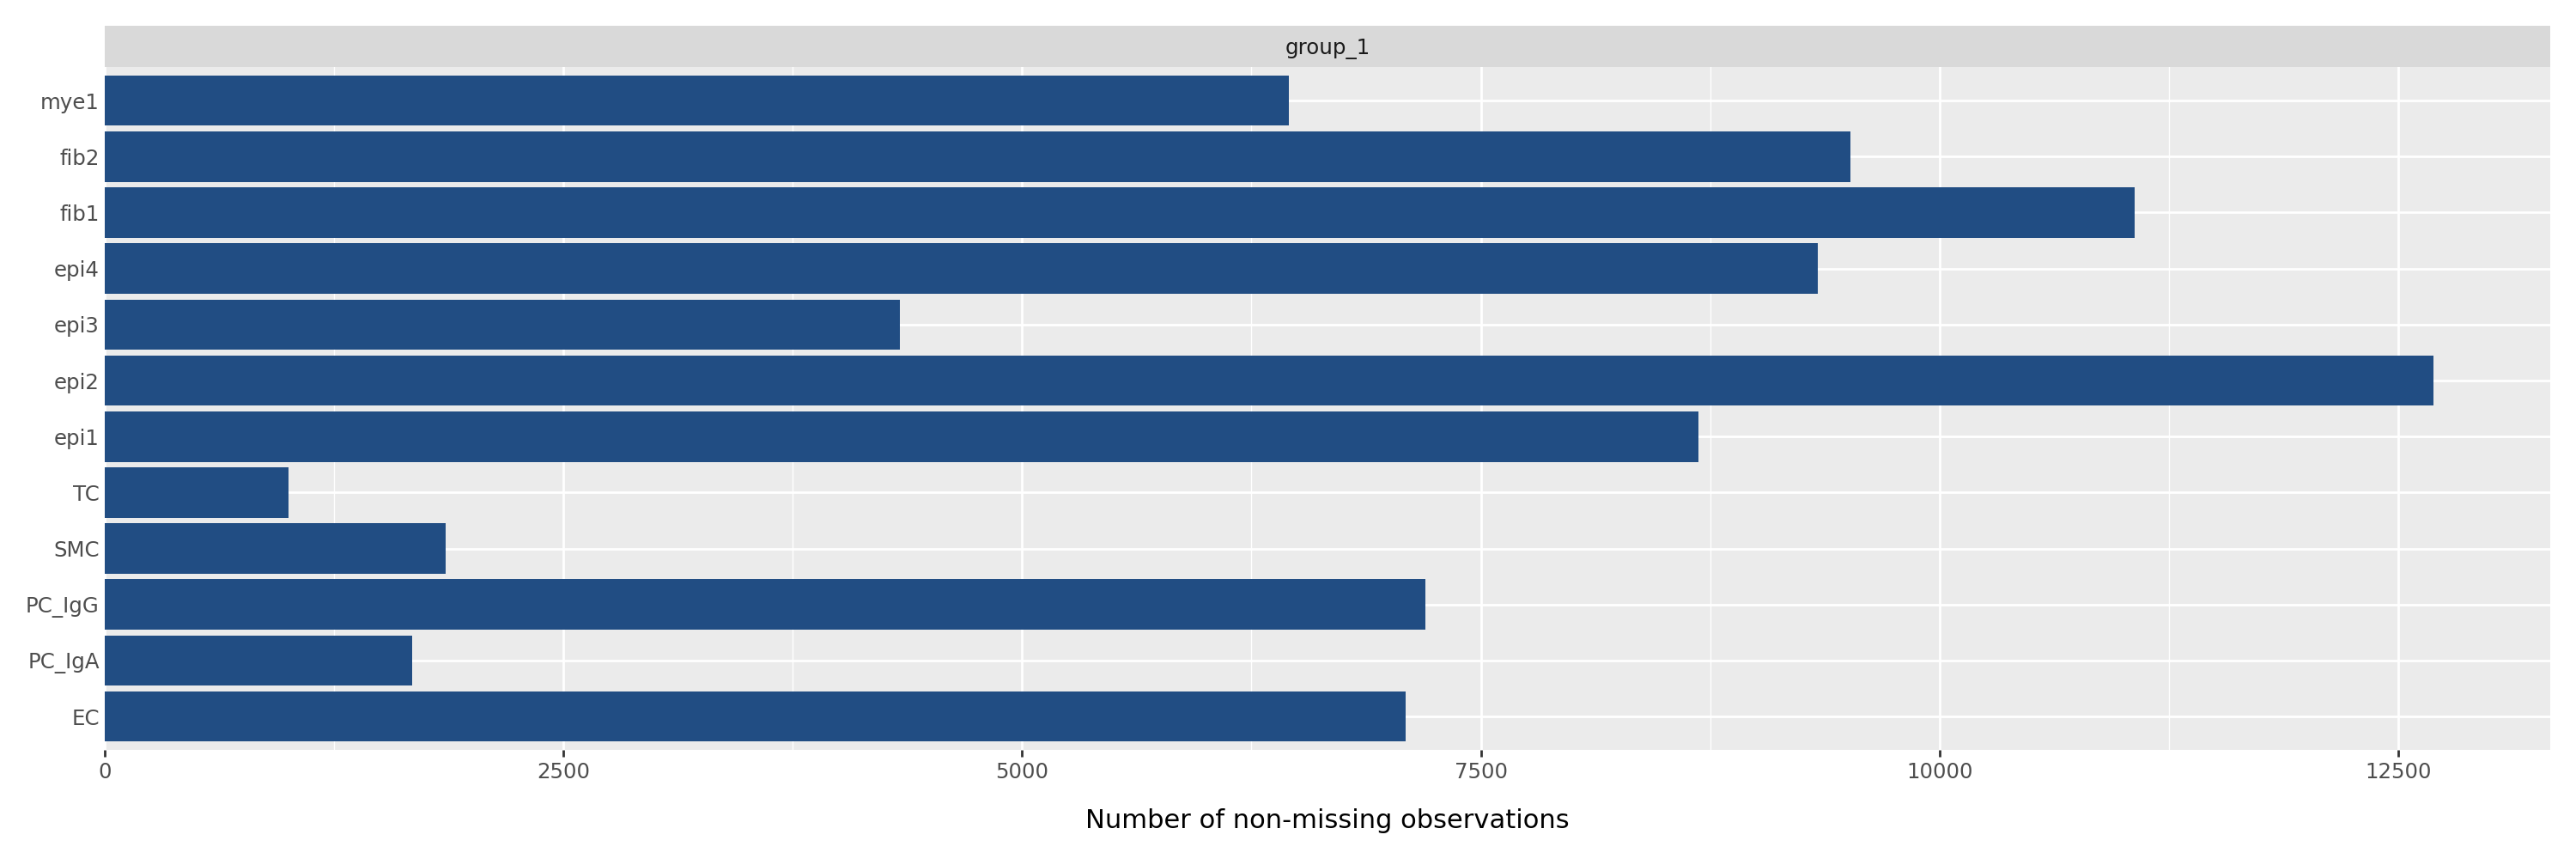

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default any

  0%|                                                                                                  | 0/500…

In [ ]:
model = mfl.MOFAFLEX(
    mdata_new,
    mfl.ModelOptions(n_factors=15, factor_prior="Normal", likelihoods="Normal"),
    mfl.TrainingOptions(batch_size=2000, 
                        n_particles=10,
                        seed=1, 
                        lr=0.005,
                        max_epochs=500,
                        save_path='/g/stegle/aalsayah/repos/data/mofa_models/model_232_nor4.hdf5',
                        early_stopper_patience=25,
                        mofa_compat="full")
                        )

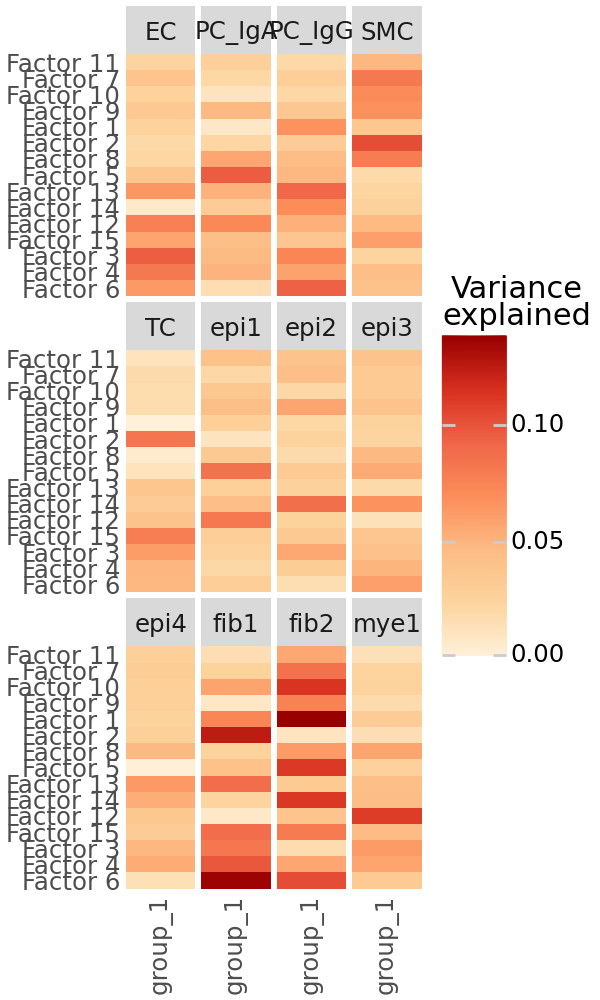

In [13]:
# in the SAME Python/mofapy2 env you trained in
mfl.pl.variance_explained(model, group_by="view")

In [14]:
import numpy as np

def calculate_variance_explained(
    Z,                 # (N, K) latent factor matrix
    W_list,            # list of length M; each W[m] is (D_m, K)
    Y_list,            # list of length M; each Y[m] is (N, D_m)
    groups,            # (N,) array-like of group labels (can be strings/ints)
    masks,             # list of length M; each mask[m] is (N, D_m) boolean (True = missing)
    total=False        # if True: total R^2 per view; else: R^2 per factor
):
    """
    Compute variance explained (R^2) by factors per group and view.

    Returns
    -------
    r2 : list (length G)
        If total=False: each item is an array of shape (M, K) with R^2 per view and factor.
        If total=True : each item is an array of shape (M,)   with total R^2 per view.
    """
    # Basic dims
    M = len(Y_list)
    K = Z.shape[1]

    # Preserve first-occurrence order of unique groups
    groups = np.asarray(groups)
    unique_groups, idx = np.unique(groups, return_index=True)
    unique_groups = unique_groups[np.argsort(idx)]
    G = len(unique_groups)

    # Allocate output
    if total:
        r2 = [np.zeros(M) for _ in range(G)]
    else:
        r2 = [np.zeros((M, K)) for _ in range(G)]

    # Loop over views and groups
    for m in range(M):
        Y = Y_list[m]            # (N, D_m)
        W = W_list[m]            # (D_m, K)
        mask = masks[m].astype(bool)  # (N, D_m); True means missing
        for g, gval in enumerate(unique_groups):
            gg = (groups == gval)                # indices for group g
            SS = np.square(Y[gg, :]).sum()       # total sum of squares in group g for view m

            if SS == 0:
                # Avoid divide-by-zero; leave NaNs to indicate undefined R^2
                if total:
                    r2[g][m] = np.nan
                else:
                    r2[g][m, :] = np.nan
                continue

            if total:
                # Predict using all factors
                Ypred = np.dot(Z[gg, :], W.T)    # (n_g, D_m)
                Ypred[mask[gg, :]] = 0.0
                Res = np.sum((Y[gg, :] - Ypred) ** 2.0)
                r2[g][m] = 1.0 - Res / SS
            else:
                # Variance explained per factor
                for k in range(K):
                    Ypred = np.outer(Z[gg, k], W[:, k])  # (n_g, D_m)
                    Ypred[mask[gg, :]] = 0.0
                    Res = np.sum((Y[gg, :] - Ypred) ** 2.0)
                    r2[g][m, k] = 1.0 - Res / SS

    return r2


In [15]:
Z = model.get_factors()

In [16]:
W_list = model.get_weights()

In [18]:
groups = model.group_names

In [24]:
Y_list = Y

In [34]:
masks = [np.zeros_like(Ym, dtype=bool) for Ym in Y]


In [35]:
calculate_variance_explained(    
    Z,                 # (N, K) latent factor matrix
    W_list,            # list of length M; each W[m] is (D_m, K)
    Y_list,            # list of length M; each Y[m] is (N, D_m)
    groups,            # (N,) array-like of group labels (can be strings/ints)
    masks,             # list of length M; each mask[m] is (N, D_m) boolean (True = missing)
    total=True        # if True: total R^2 per view; else: R^2 per factor
    )

AttributeError: 'dict' object has no attribute 'shape'

# Model results

In [7]:
model_sns = mfl.MOFAFLEX.load("/g/stegle/aalsayah/repos/data/mofa_models/model_232_sns")

In [8]:
model_nor = mfl.MOFAFLEX.load("/g/stegle/aalsayah/repos/data/mofa_models/model_232")

In [9]:
model_gp = mfl.MOFAFLEX.load("/g/stegle/aalsayah/repos/data/mofa_models/model_232_GP")

## Total R2

In [10]:
print(model_sns.get_r2(total=True))
print(model_nor.get_r2(total=True))
print(model_gp.get_r2(total=True))

         group_1
epi4    0.411636
epi2    0.346907
epi1    0.437280
epi3    0.465665
mye1    0.457929
fib2    0.945235
EC      0.481967
TC      0.507092
SMC     0.766320
fib1    0.718685
PC_IgG  0.560660
PC_IgA  0.606943
         group_1
epi4    0.526846
epi2    0.457857
epi1    0.512651
epi3    0.548413
mye1    0.569824
fib2    0.957058
EC      0.556049
TC      0.570565
SMC     0.806497
fib1    0.839505
PC_IgG  0.617382
PC_IgA  0.622558
         group_1
epi4    0.343909
epi2    0.314902
epi1    0.406165
epi3    0.452766
mye1    0.445186
fib2    0.744794
EC      0.491040
TC      0.506850
SMC     0.718311
fib1    0.529104
PC_IgG  0.475427
PC_IgA  0.543495


In [14]:
sns_r2 = model_sns.get_r2(total=True)
sns_r2["group_1"].mean()

np.float64(0.5588599541141014)

In [ ]:
nor_r2 = model_nor.get_r2(total=True)
nor_r2["group_1"].mean()

np.float64(0.6321004154053351)

In [16]:
gp_r2 = model_gp.get_r2(total=True)
gp_r2["group_1"].mean()

np.float64(0.4976624709821087)

## Factors Correlation

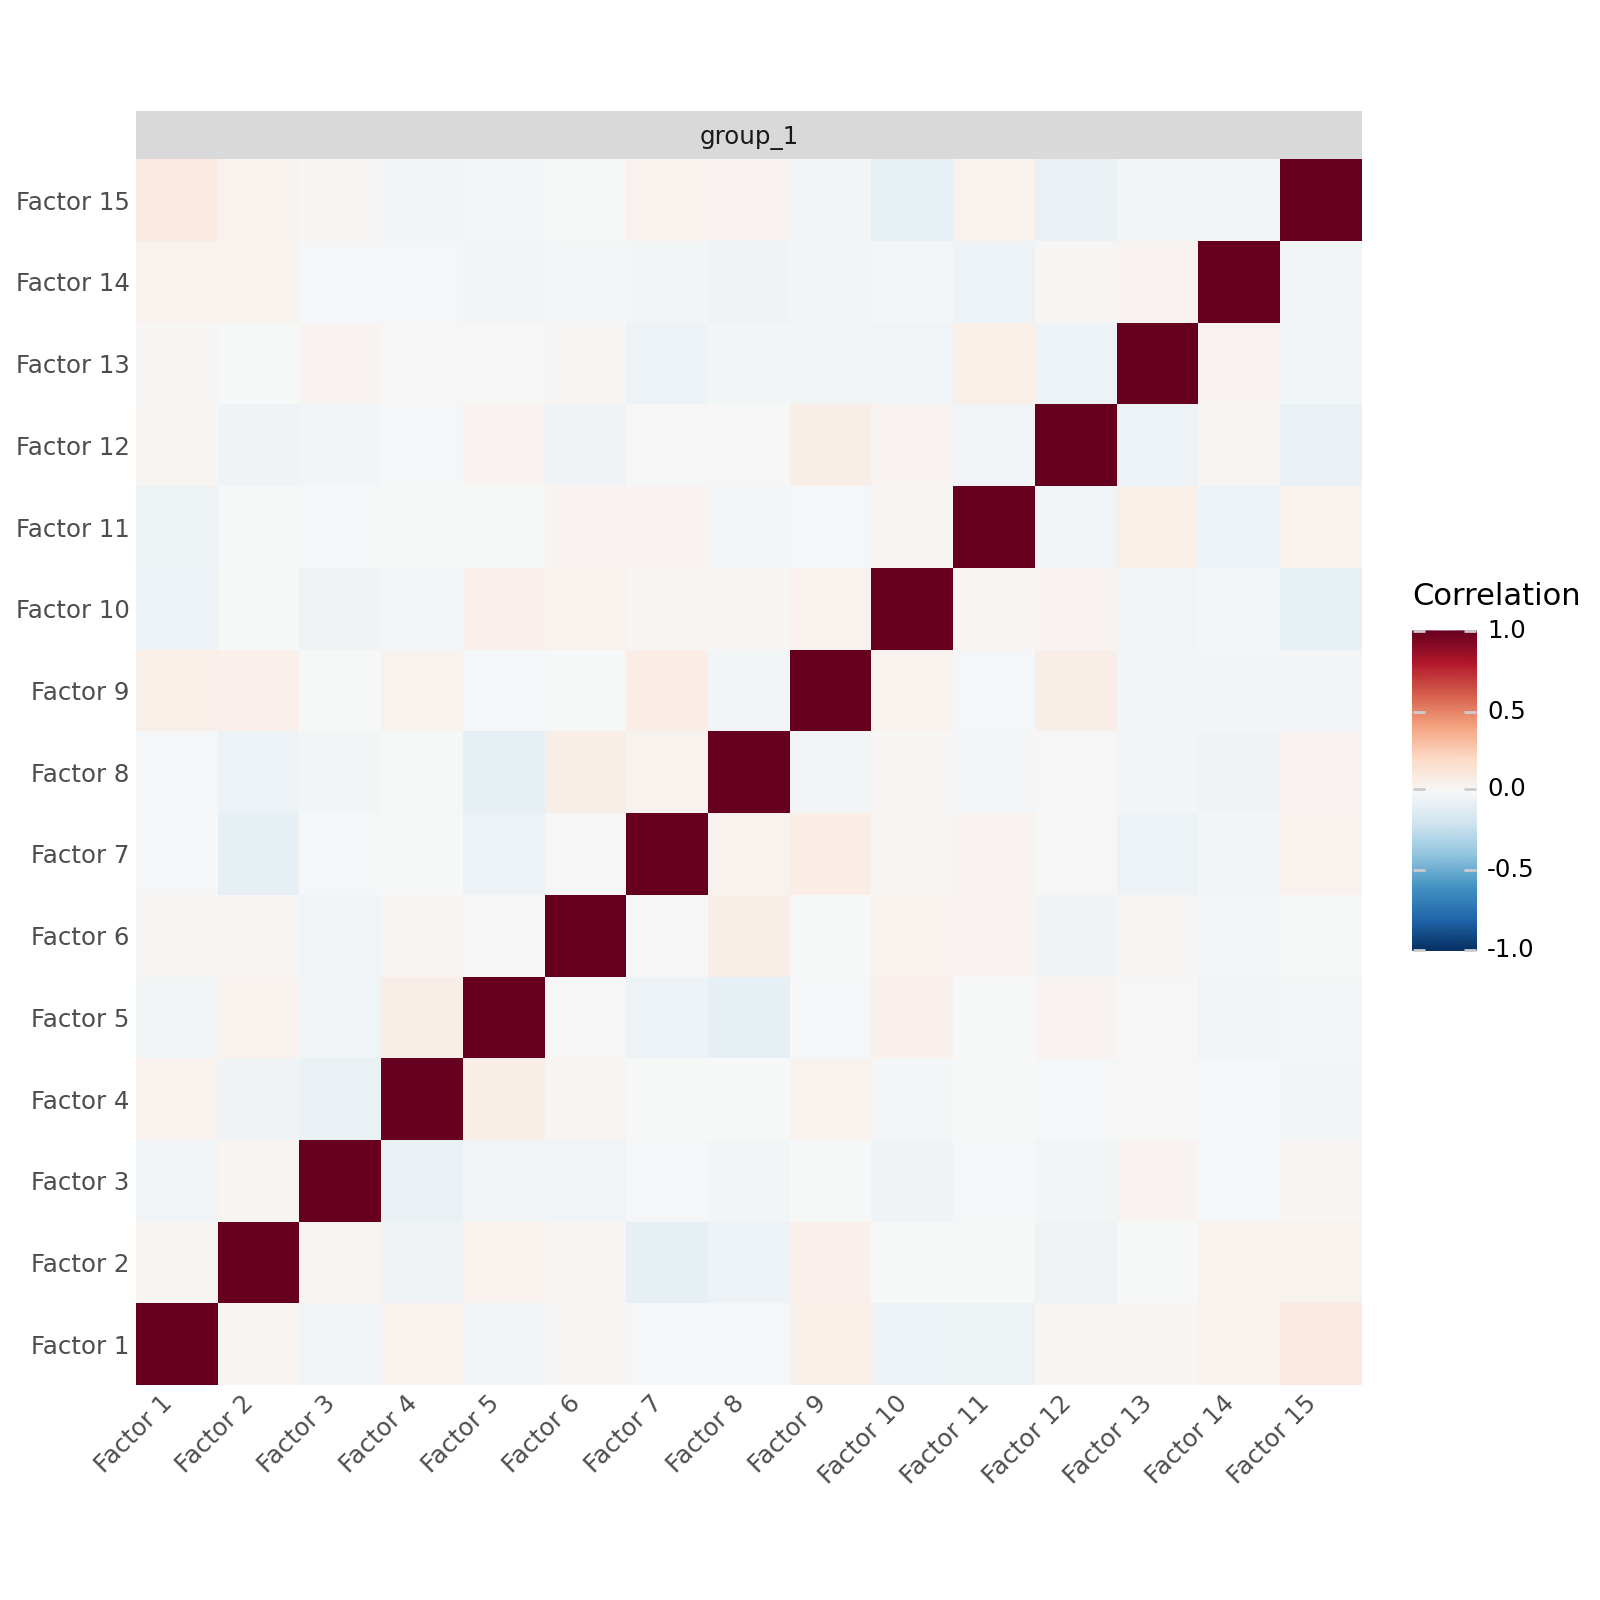

In [135]:
mfl.pl.factor_correlation(model_sns)

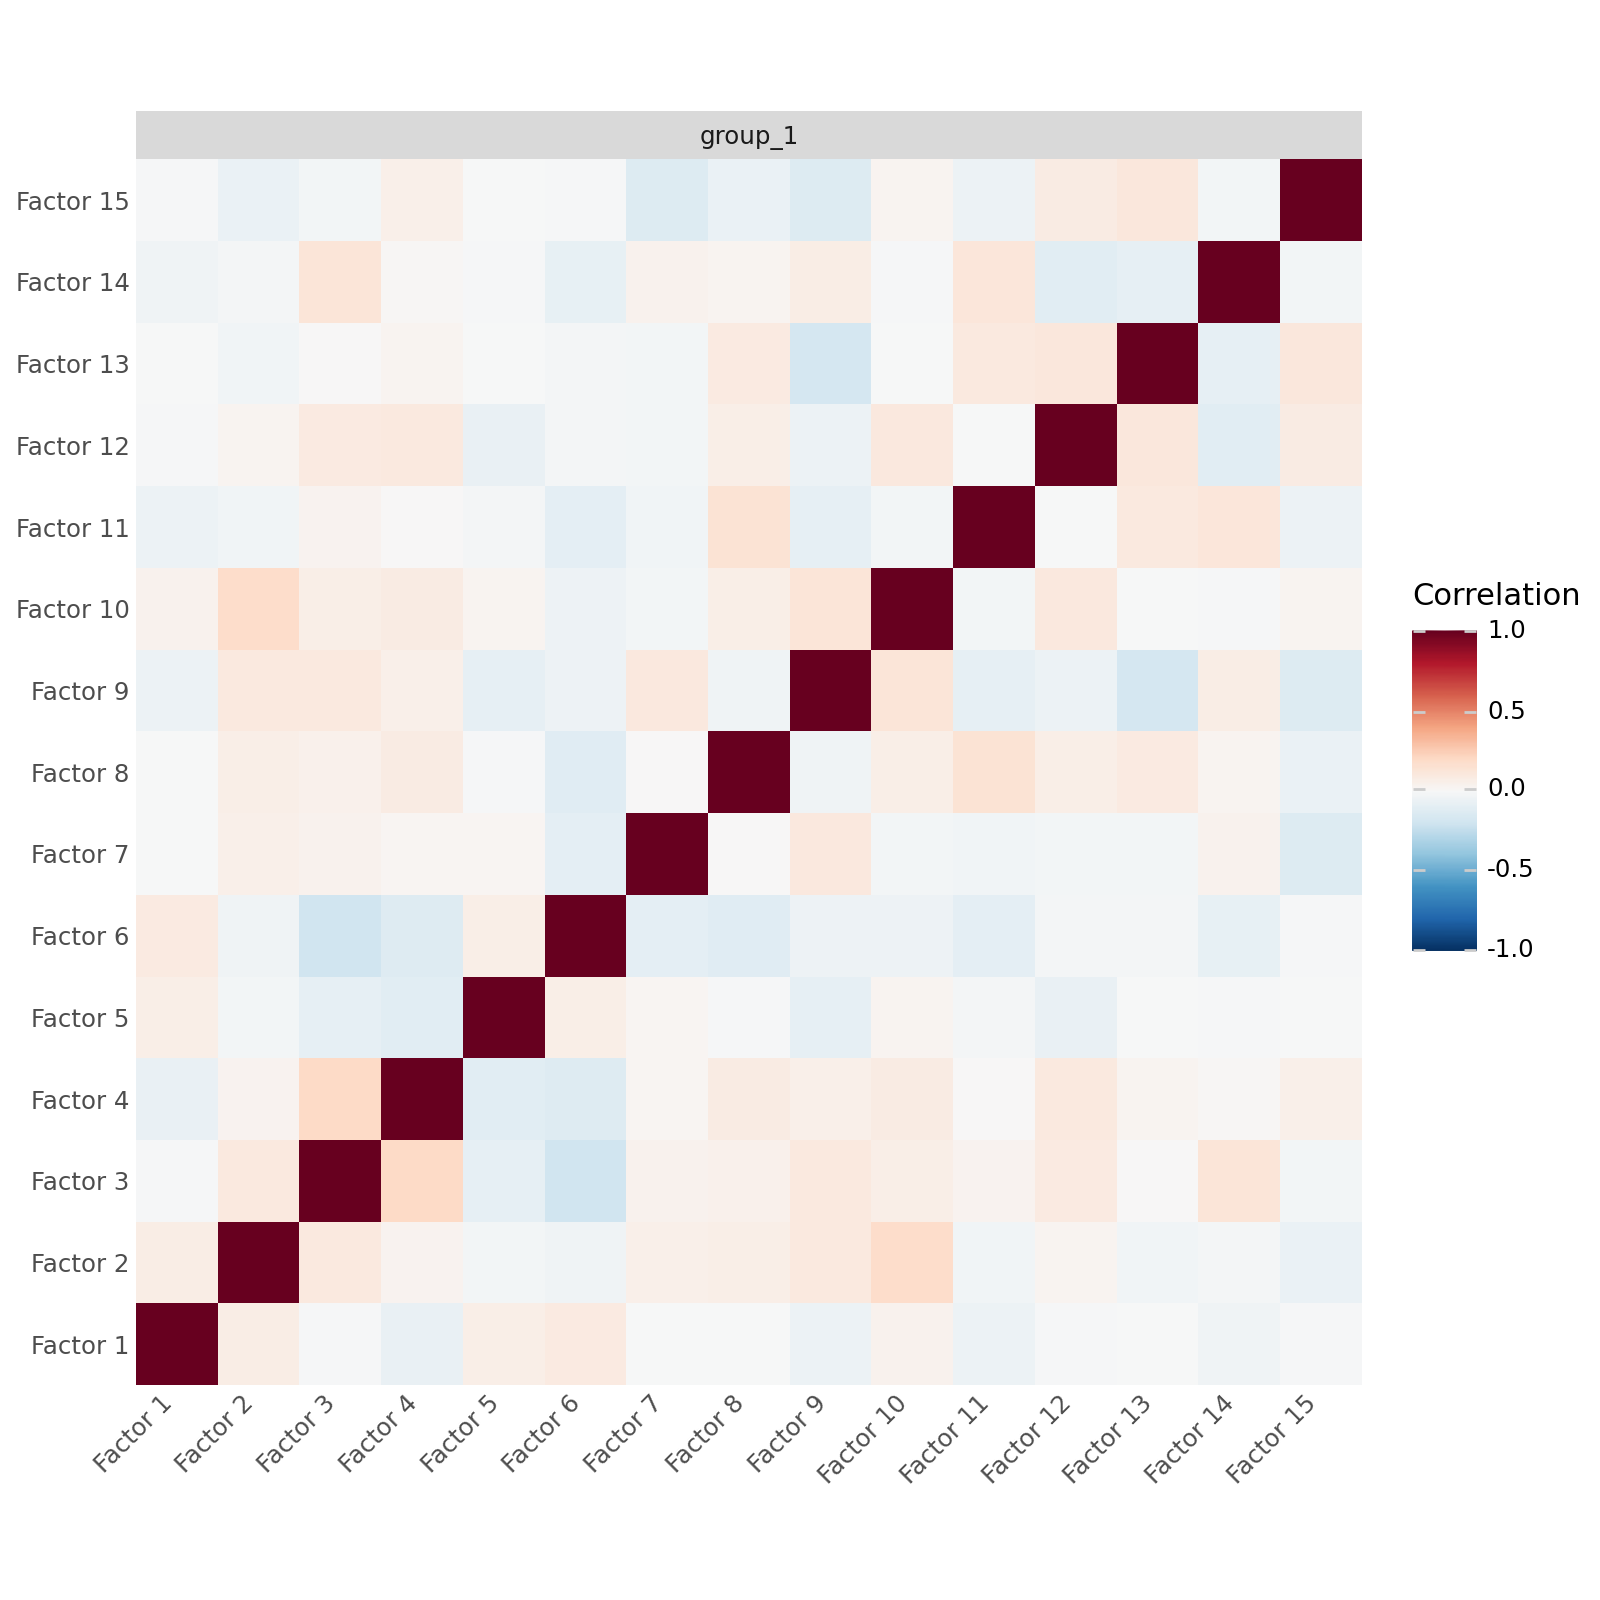

In [136]:
mfl.pl.factor_correlation(model_nor)

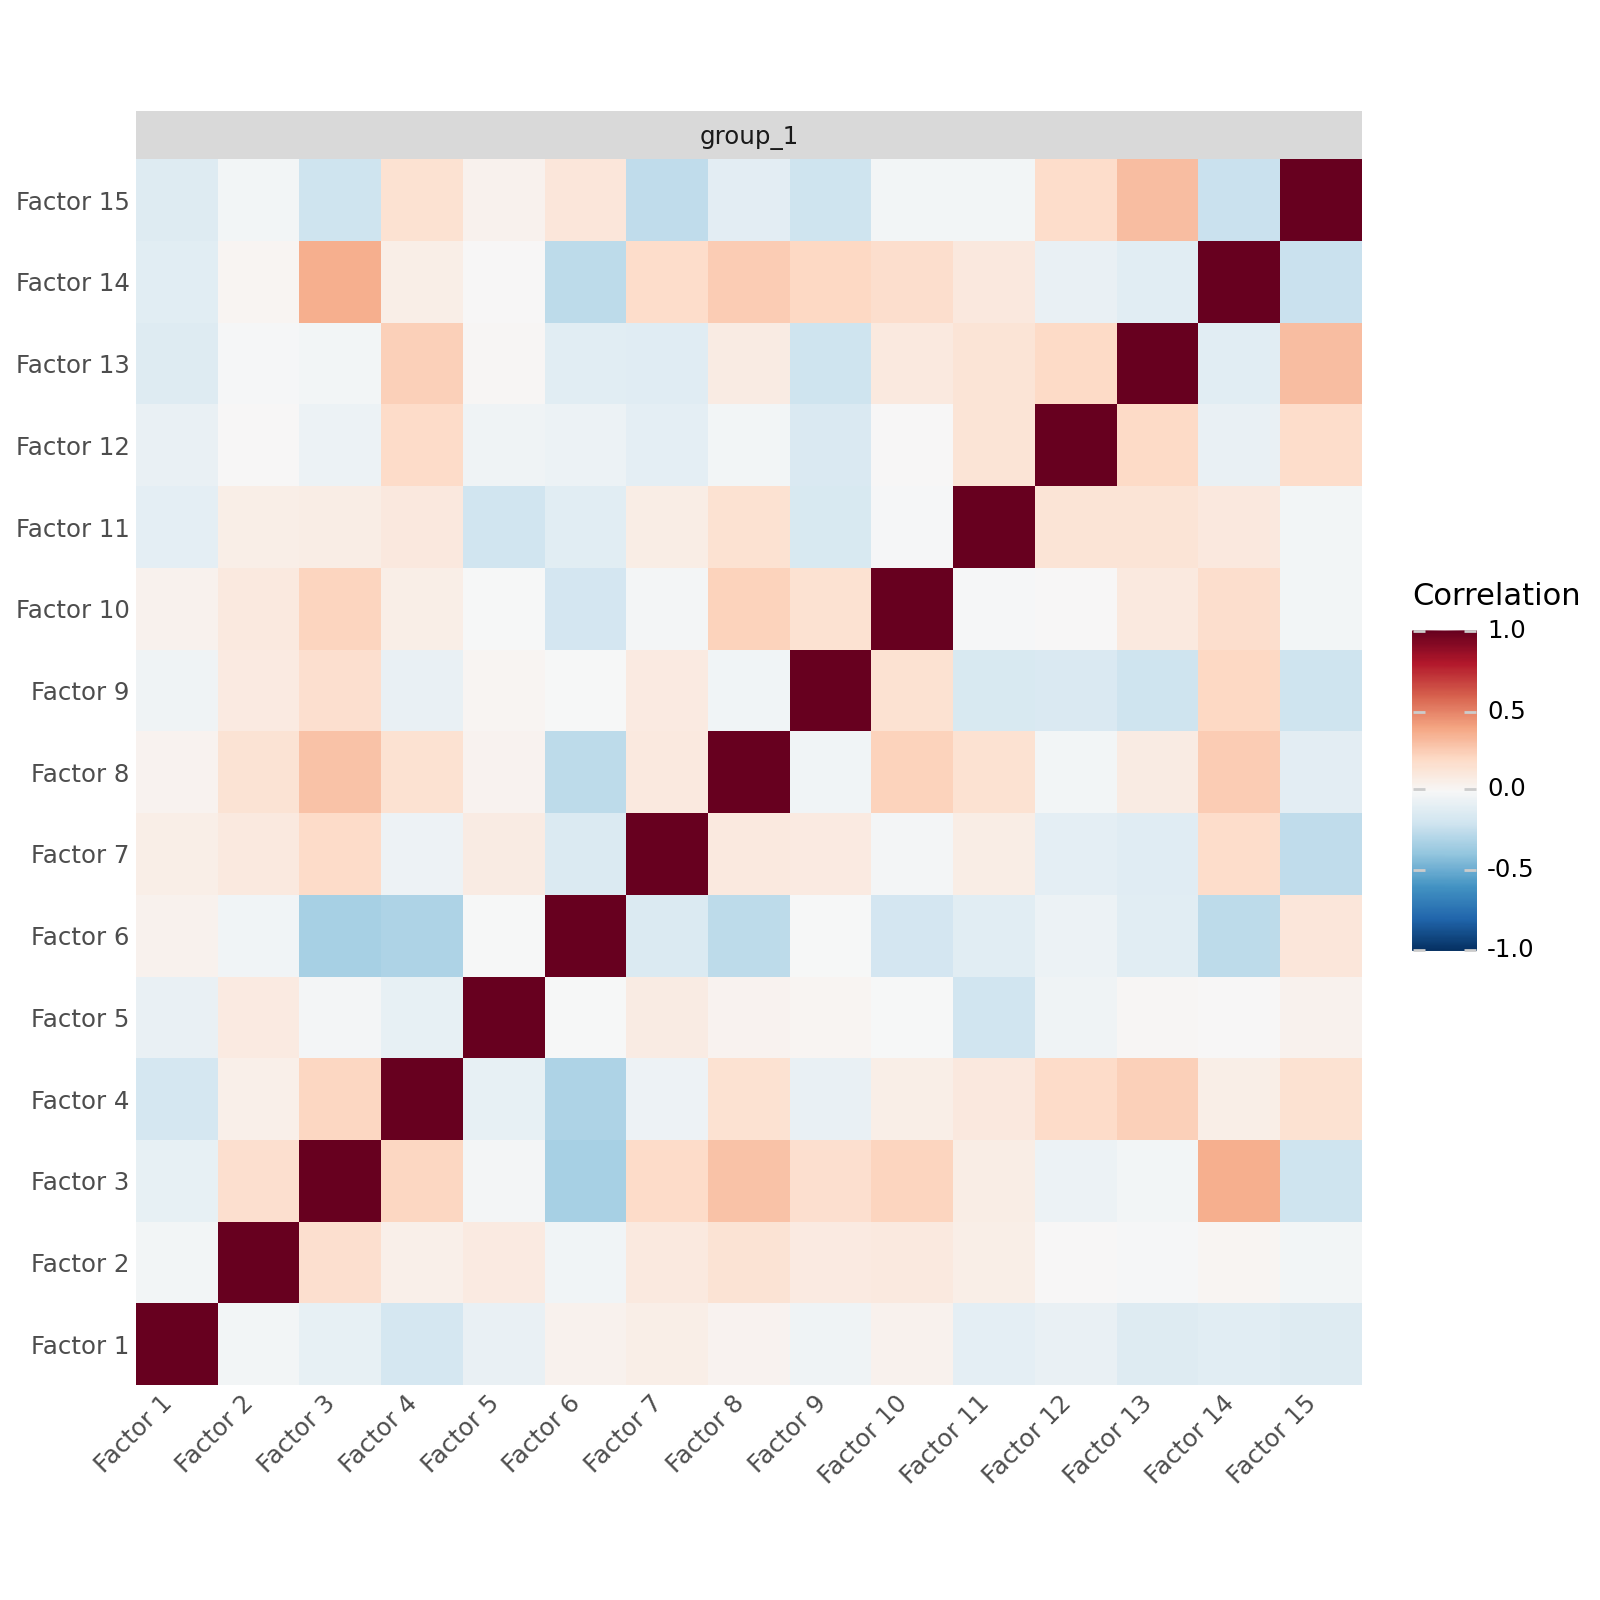

In [137]:
mfl.pl.factor_correlation(model_gp)

## Variance Explained
For non-Normal likelihoods, these values are approximate.

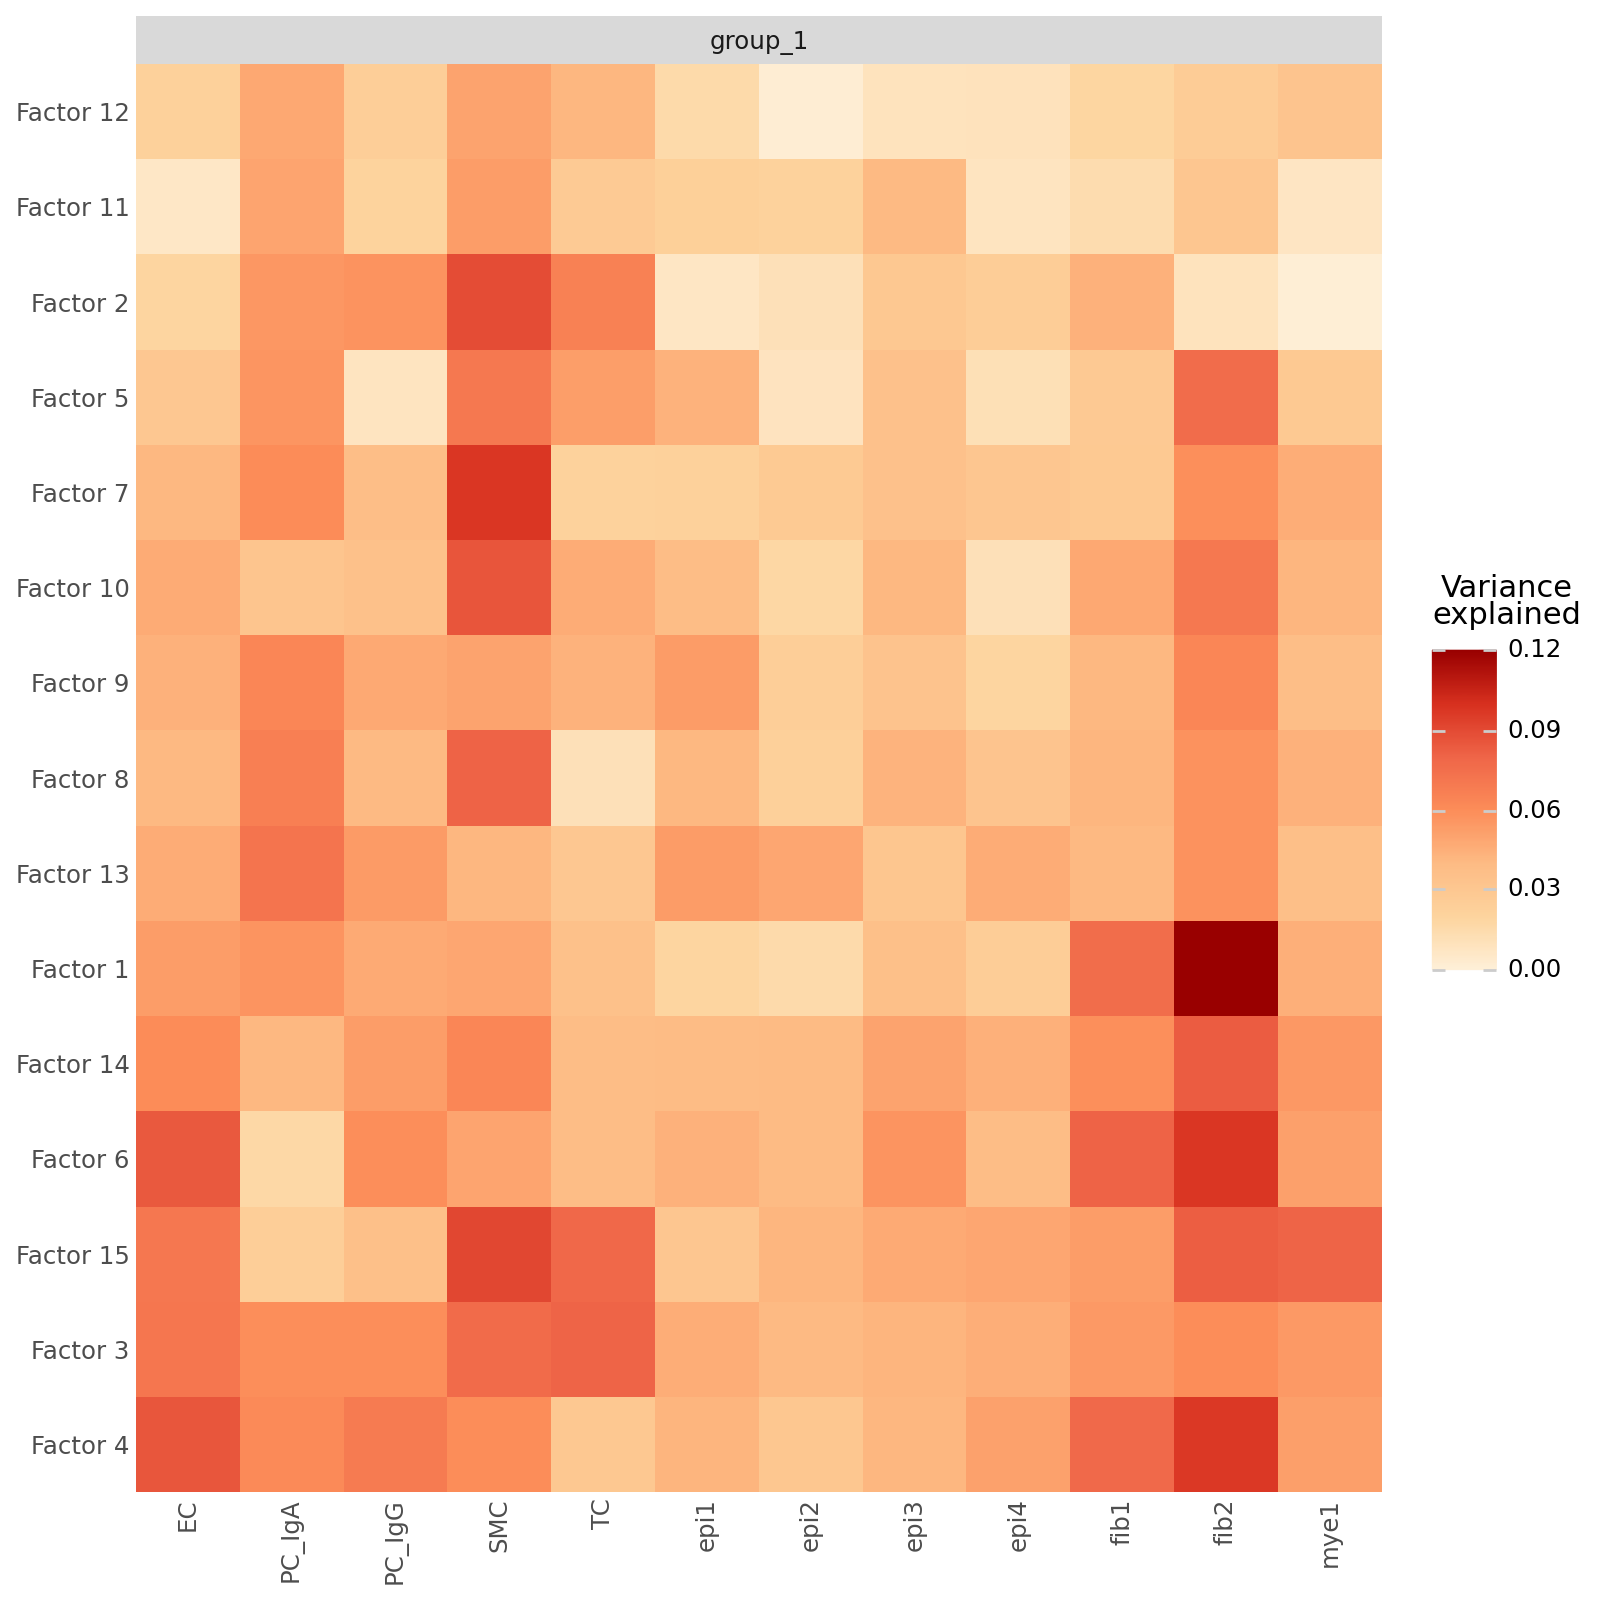

In [138]:
mfl.pl.variance_explained(model_gp, figsize= (8,8))

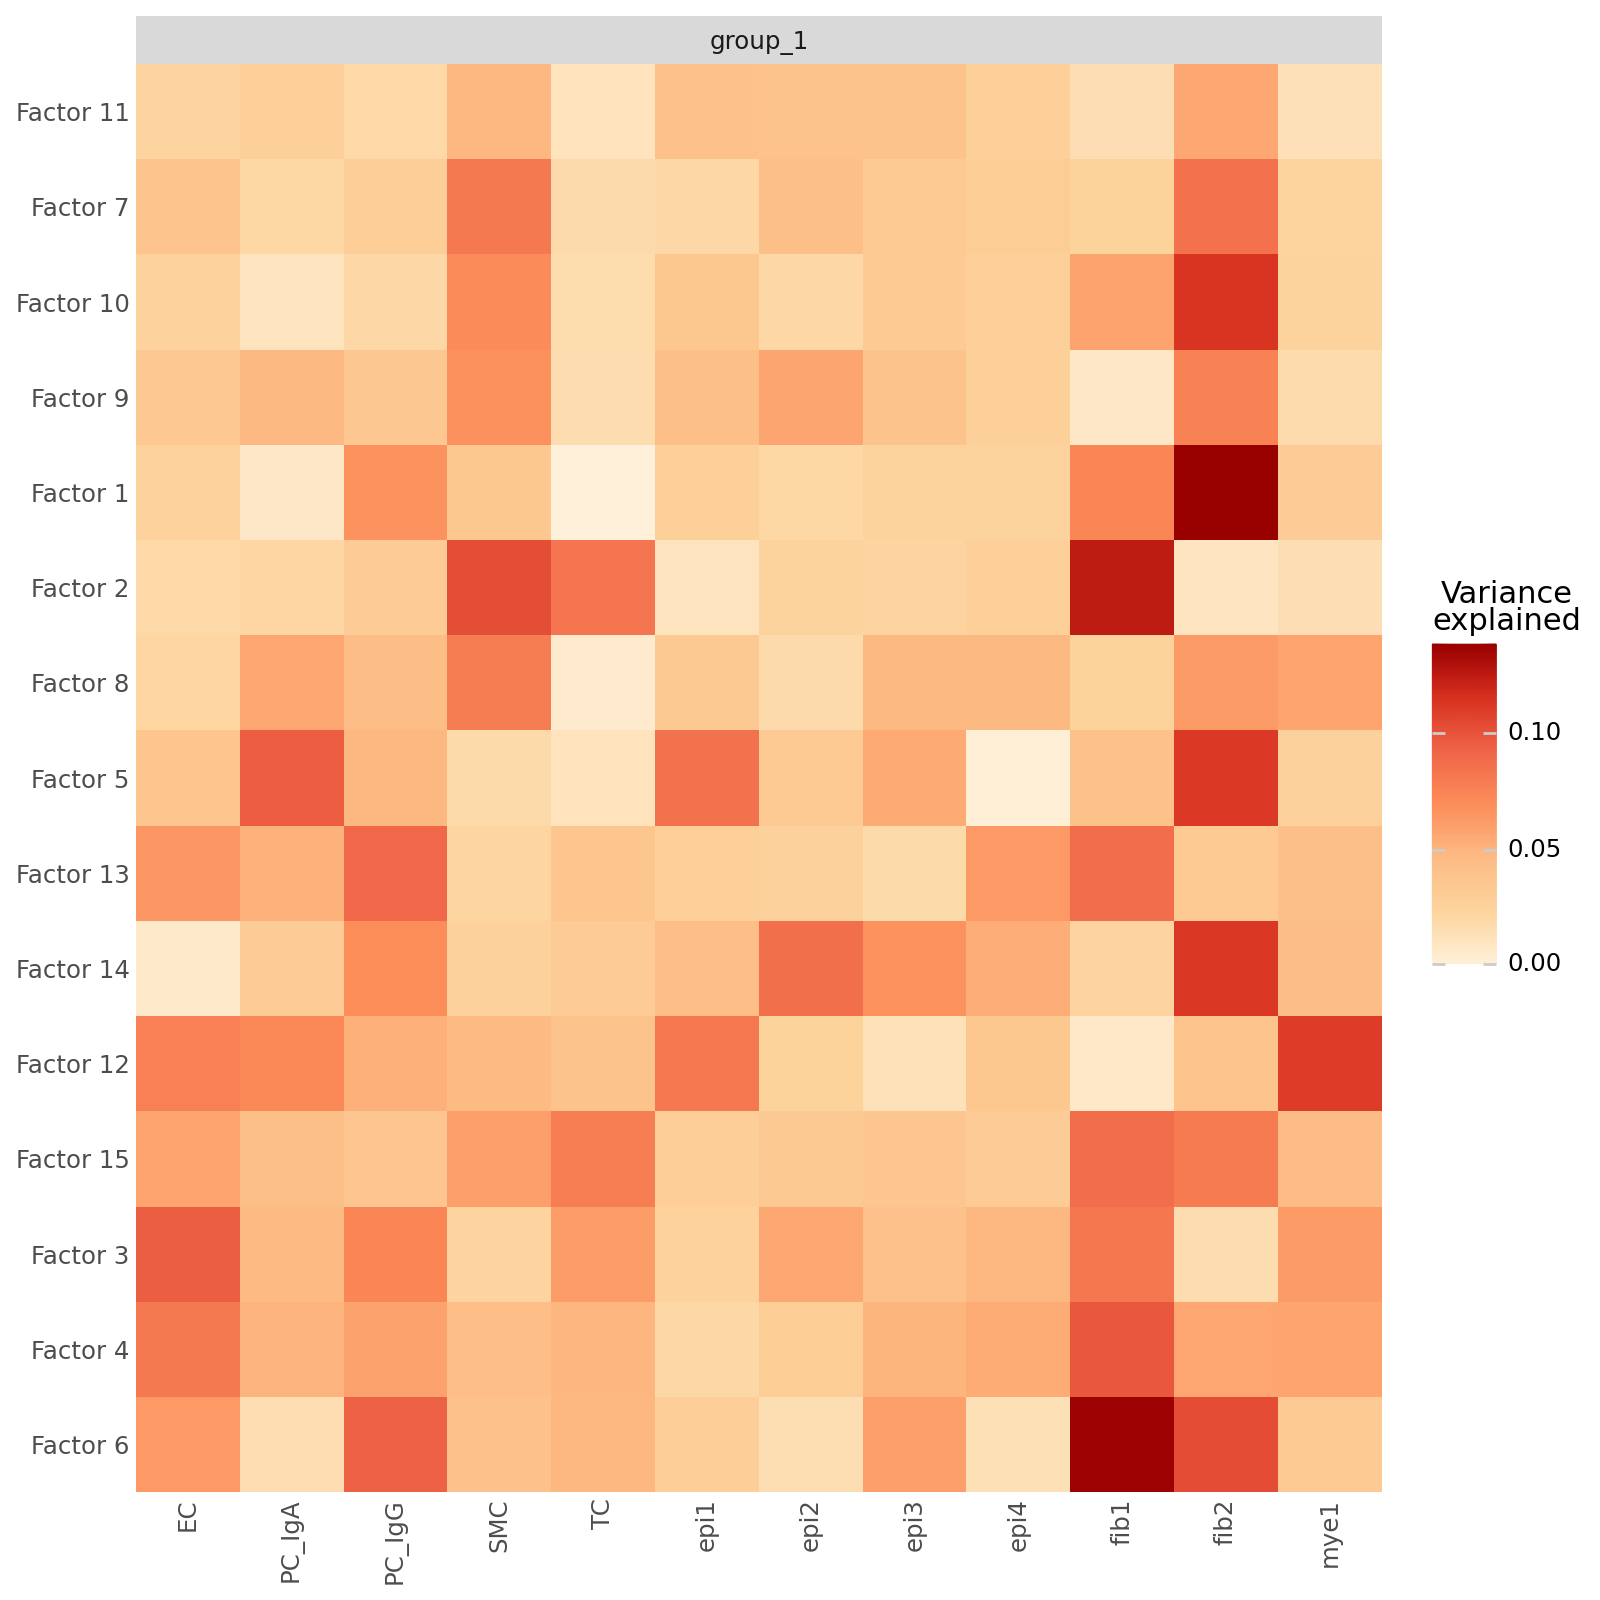

In [139]:
mfl.pl.variance_explained(model_nor, figsize= (8,8))

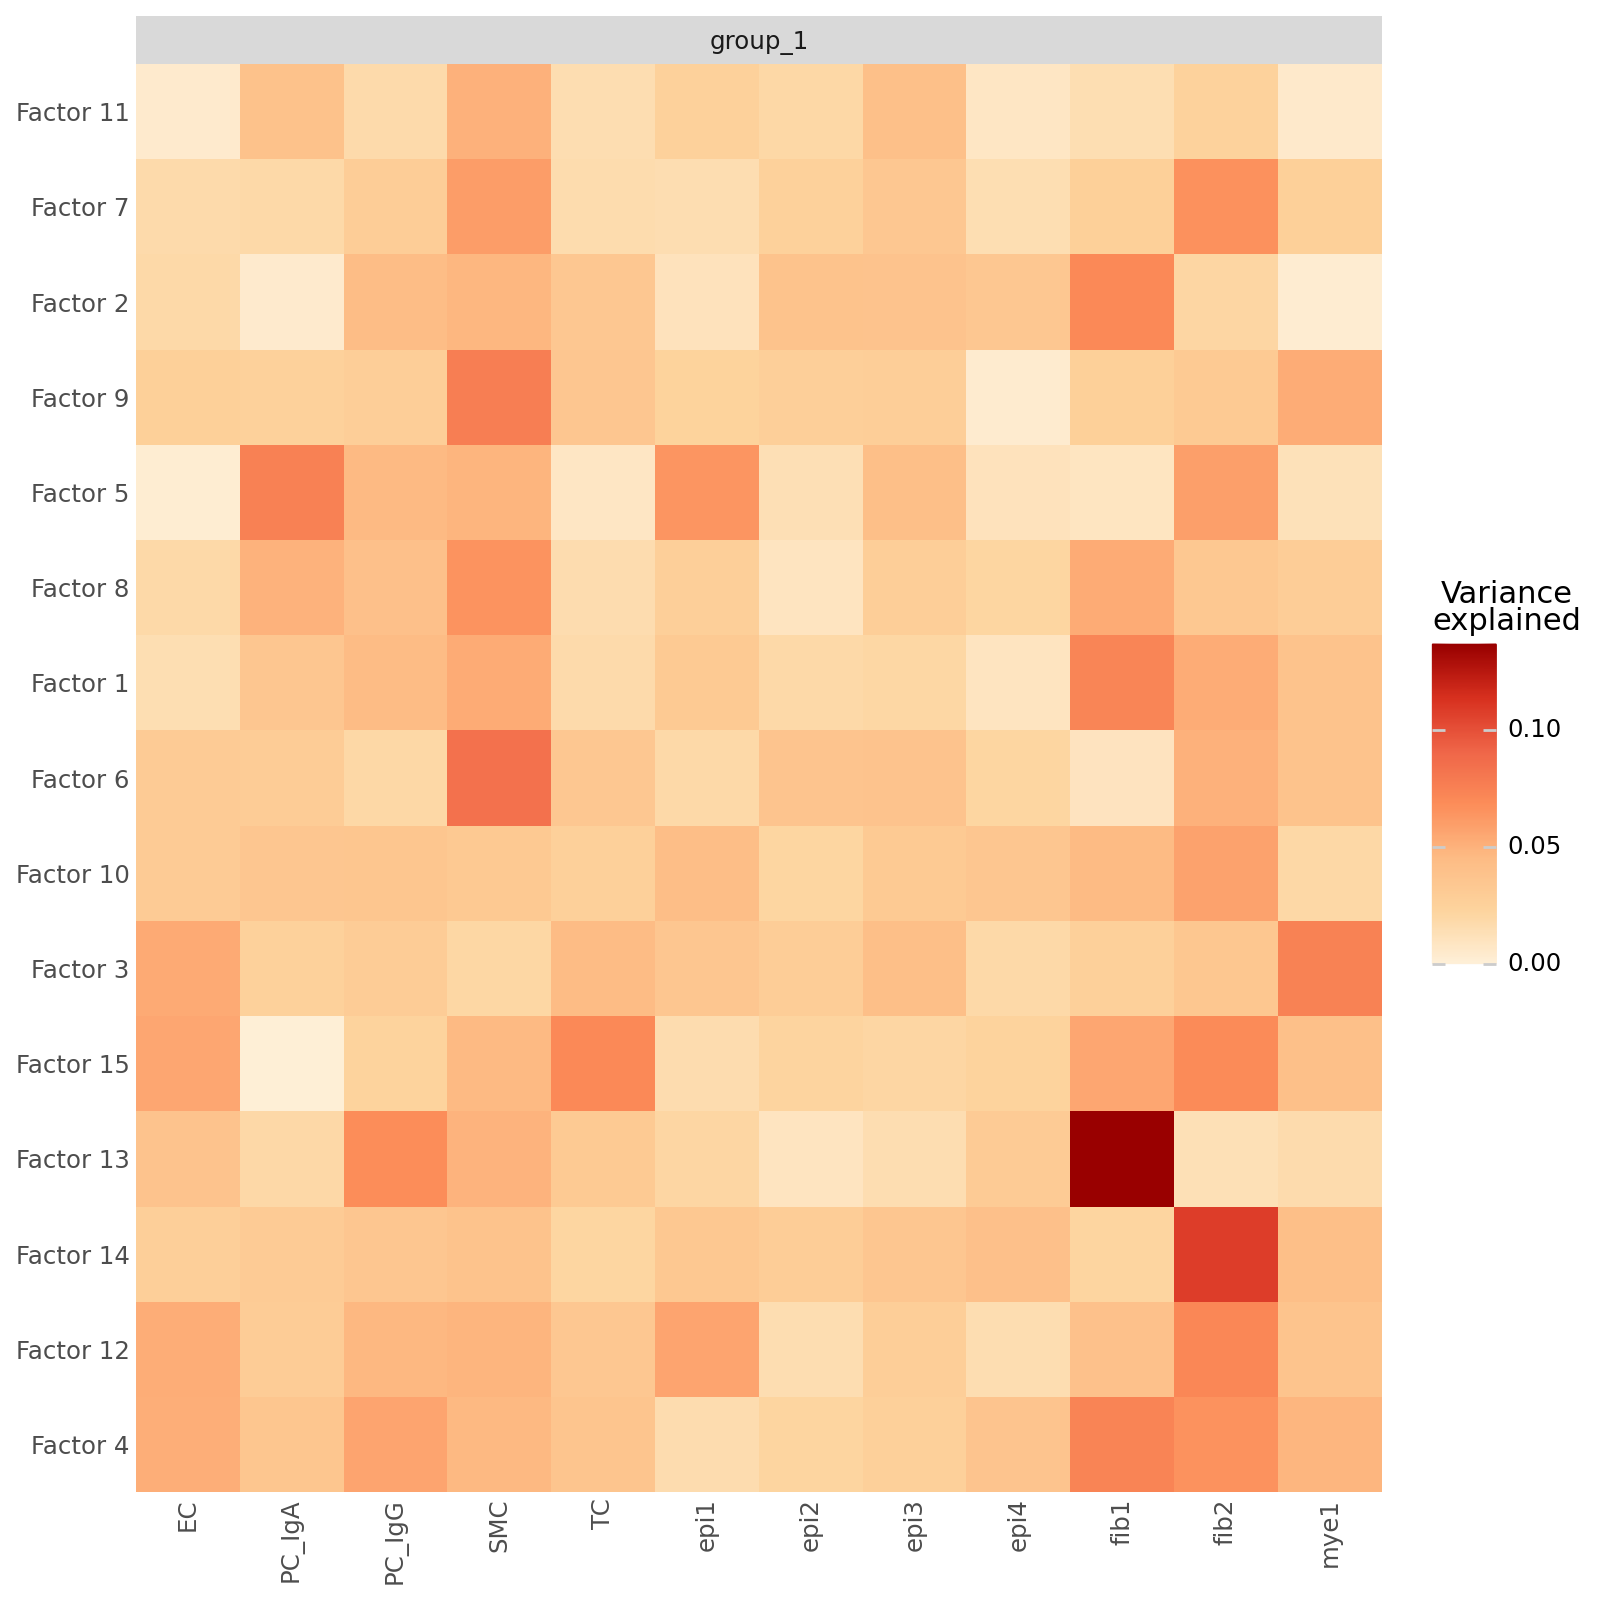

In [140]:
mfl.pl.variance_explained(model_sns, figsize= (8,8))

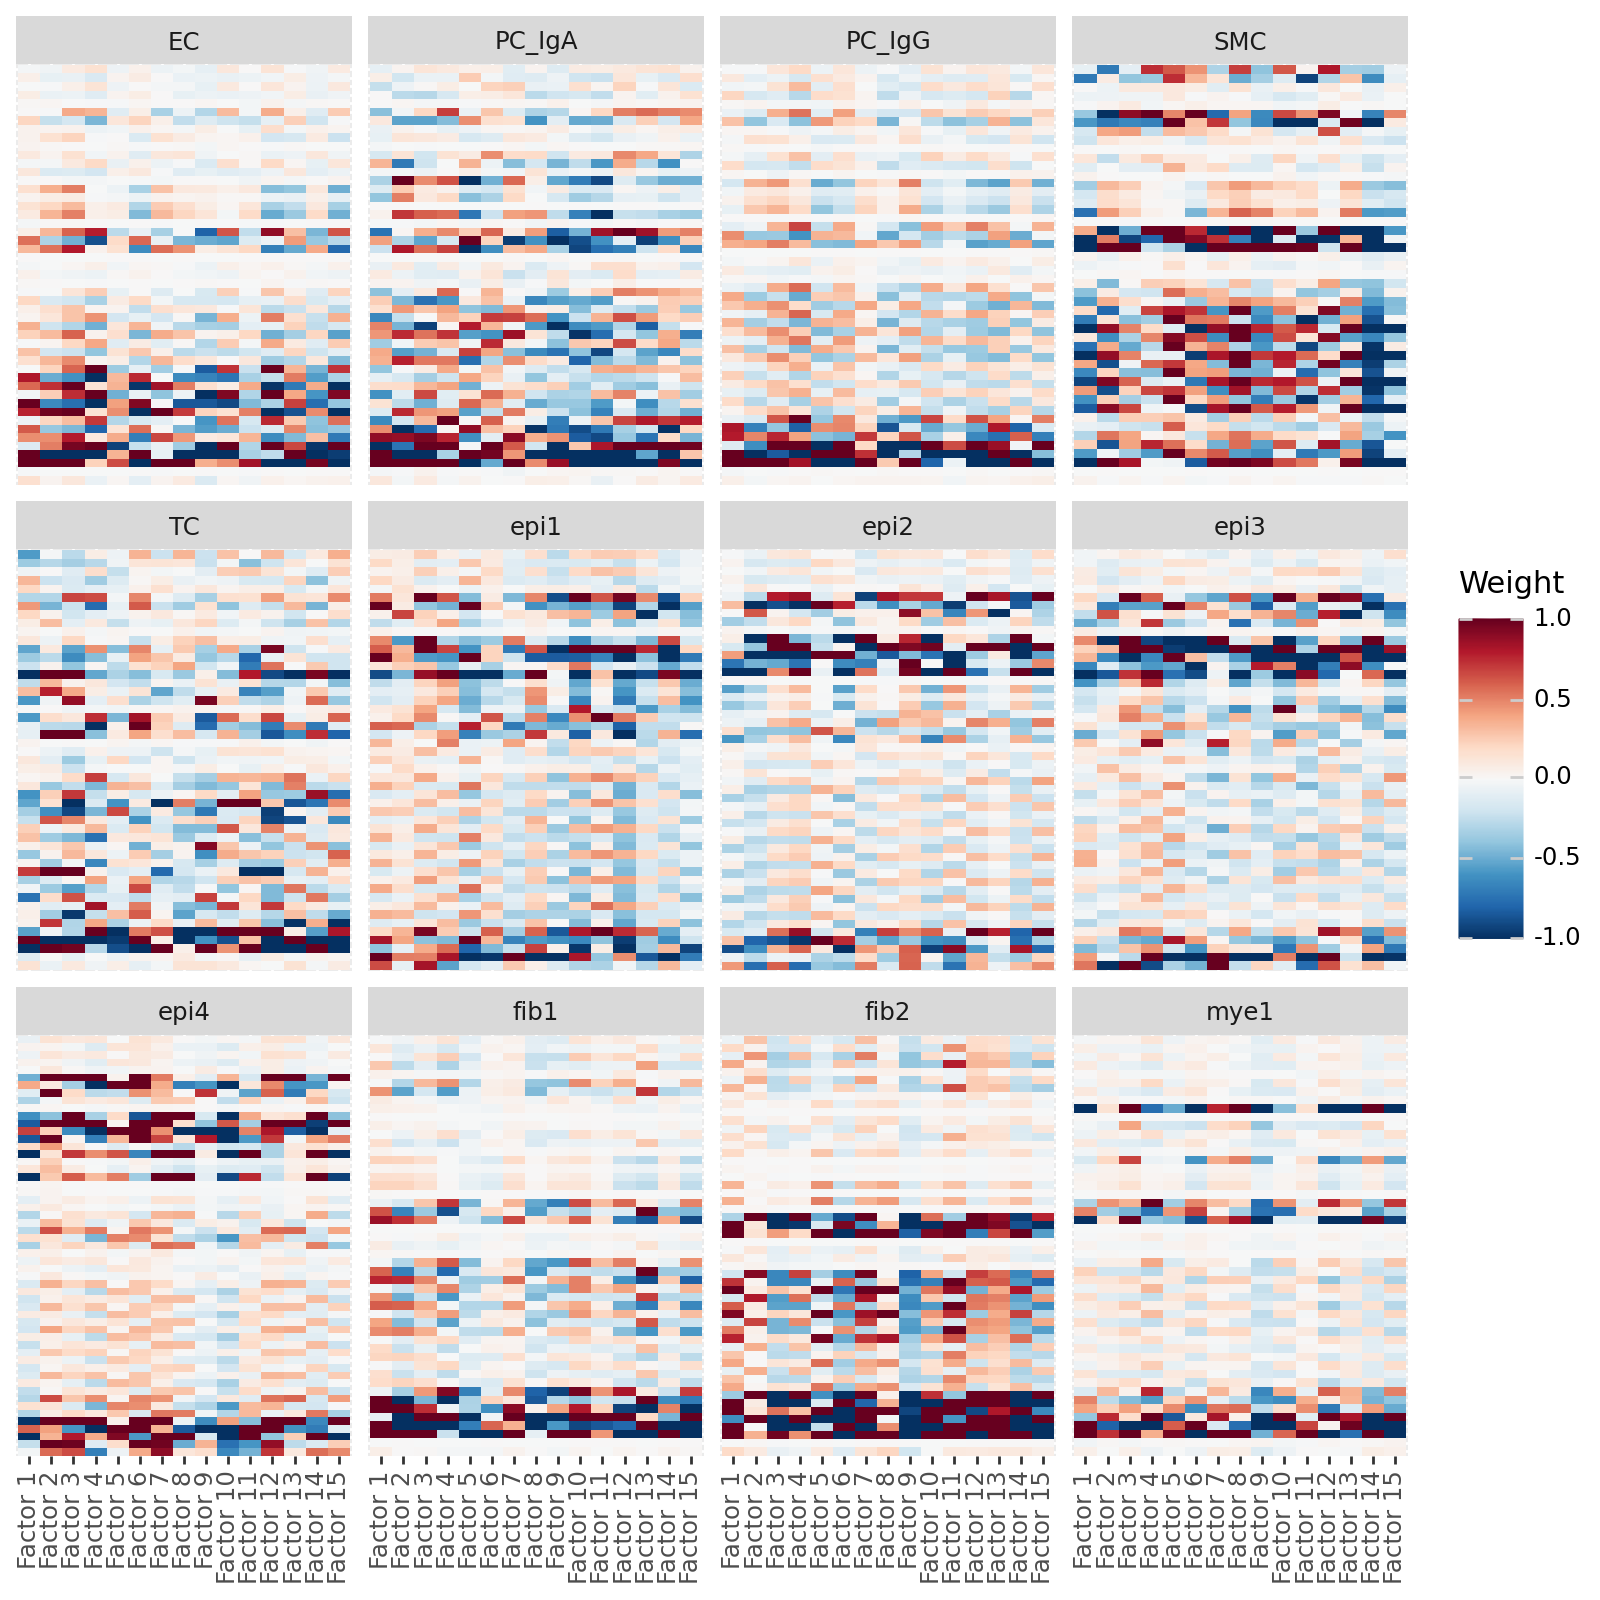

In [158]:
mfl.pl.all_weights(model_sns, figsize=(8,8))

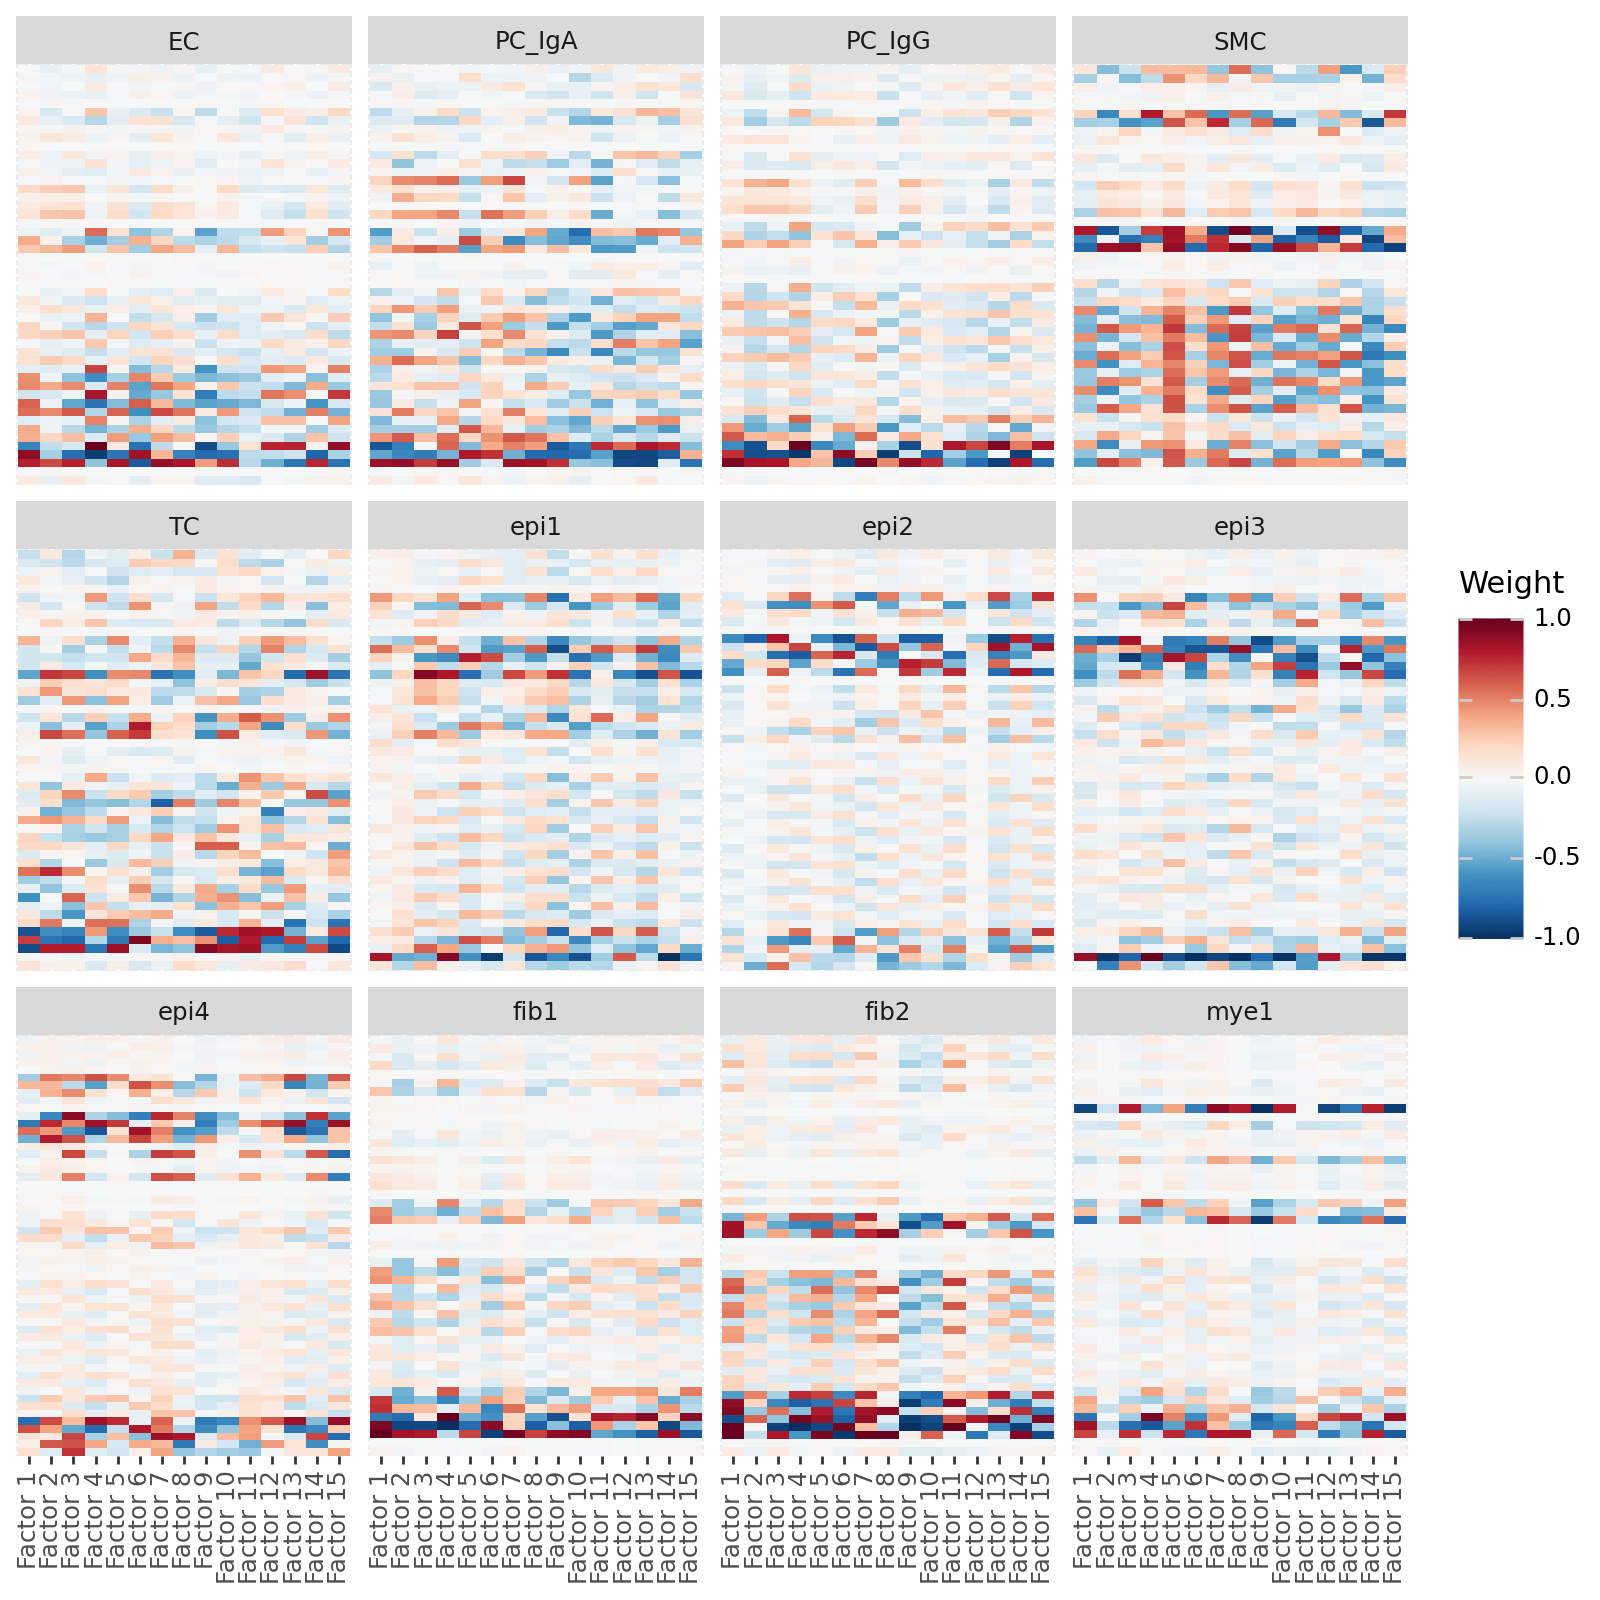

In [159]:
mfl.pl.all_weights(model_gp, figsize=(8,8))

## Plot weight

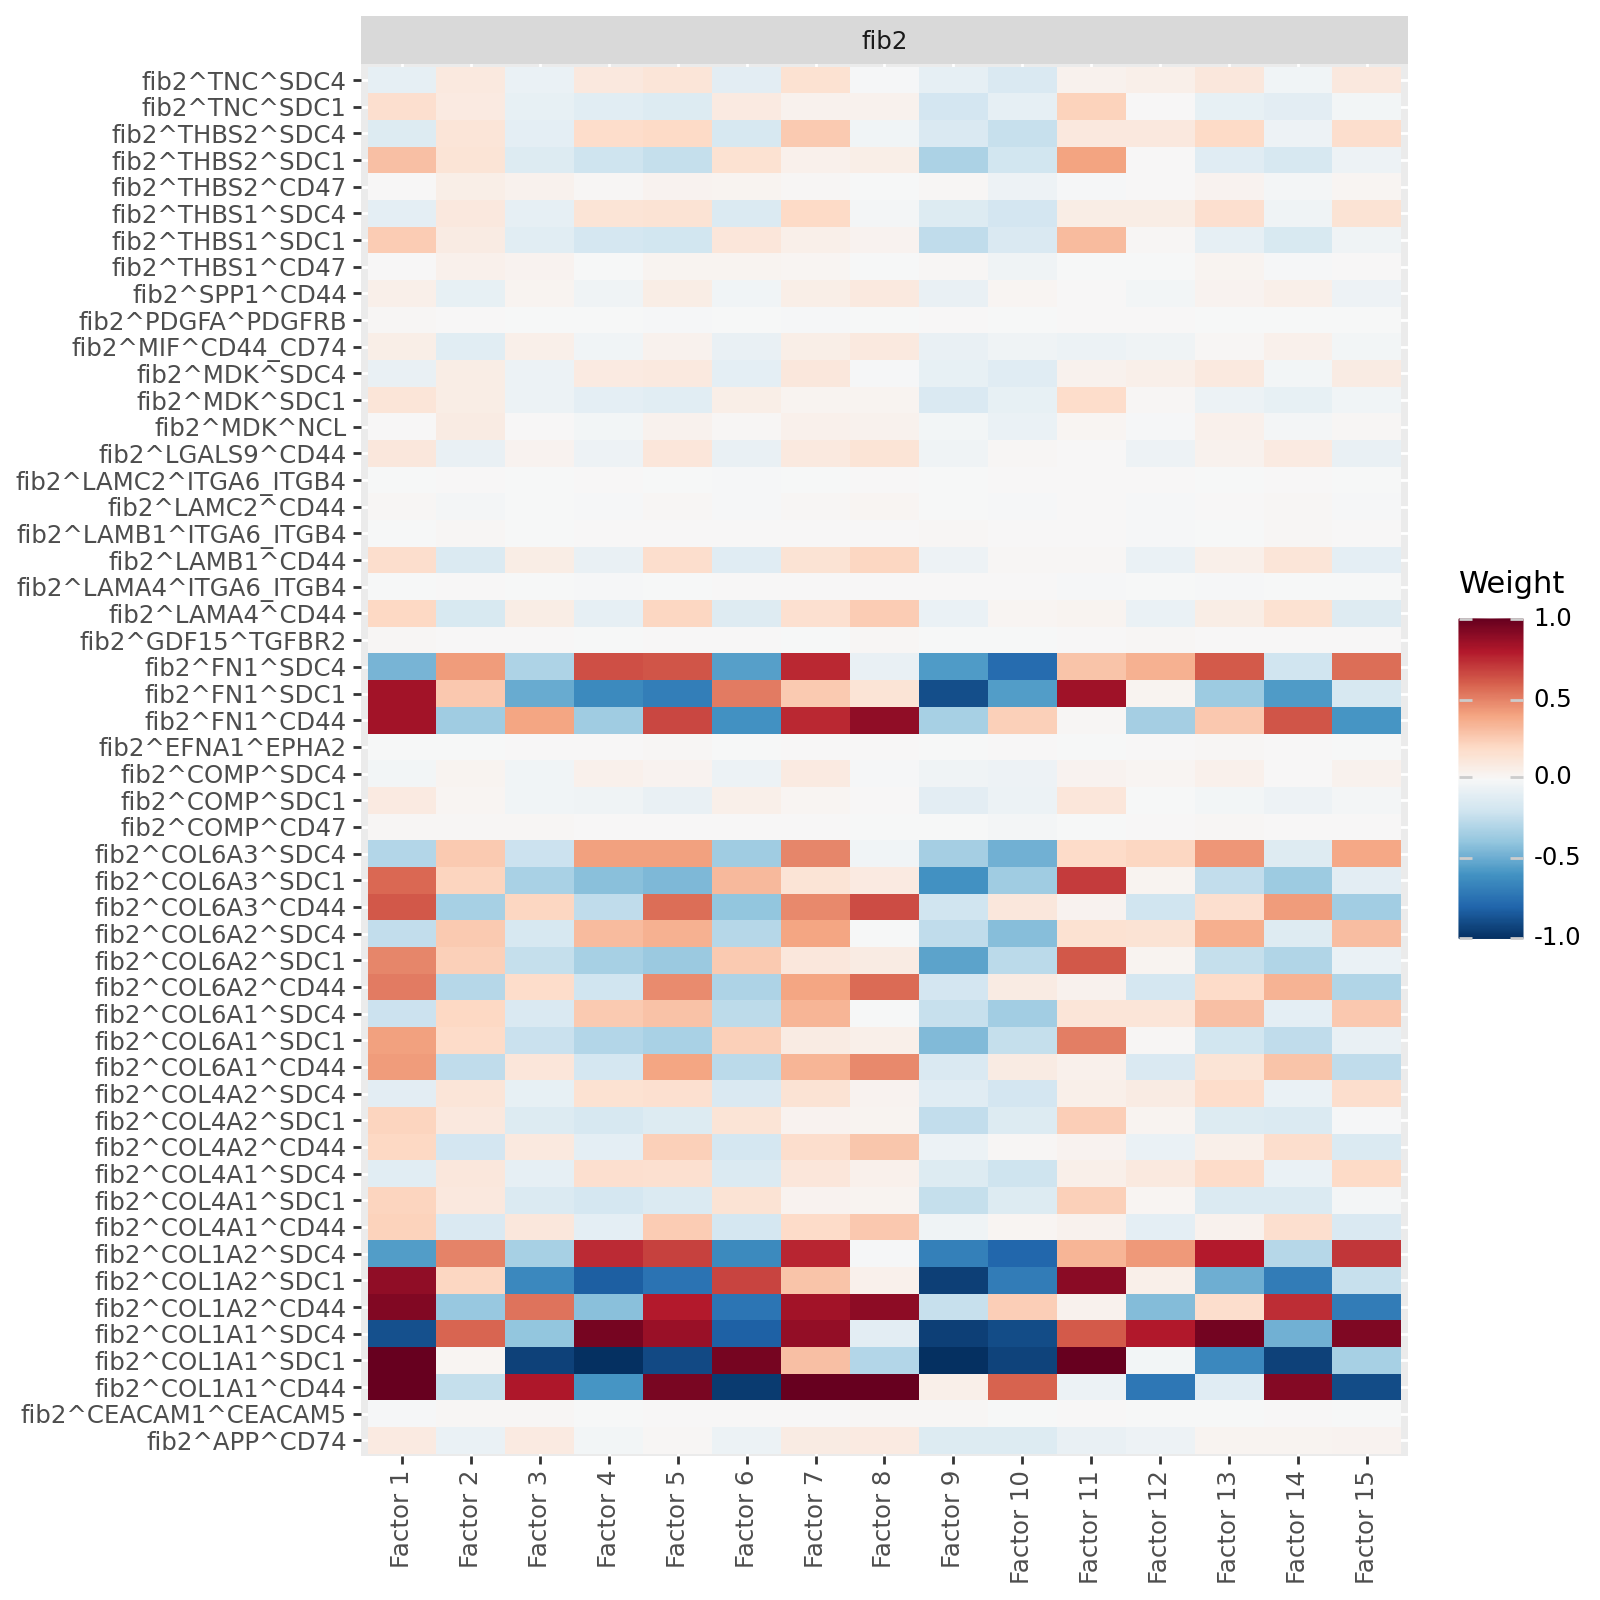

In [121]:
mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)

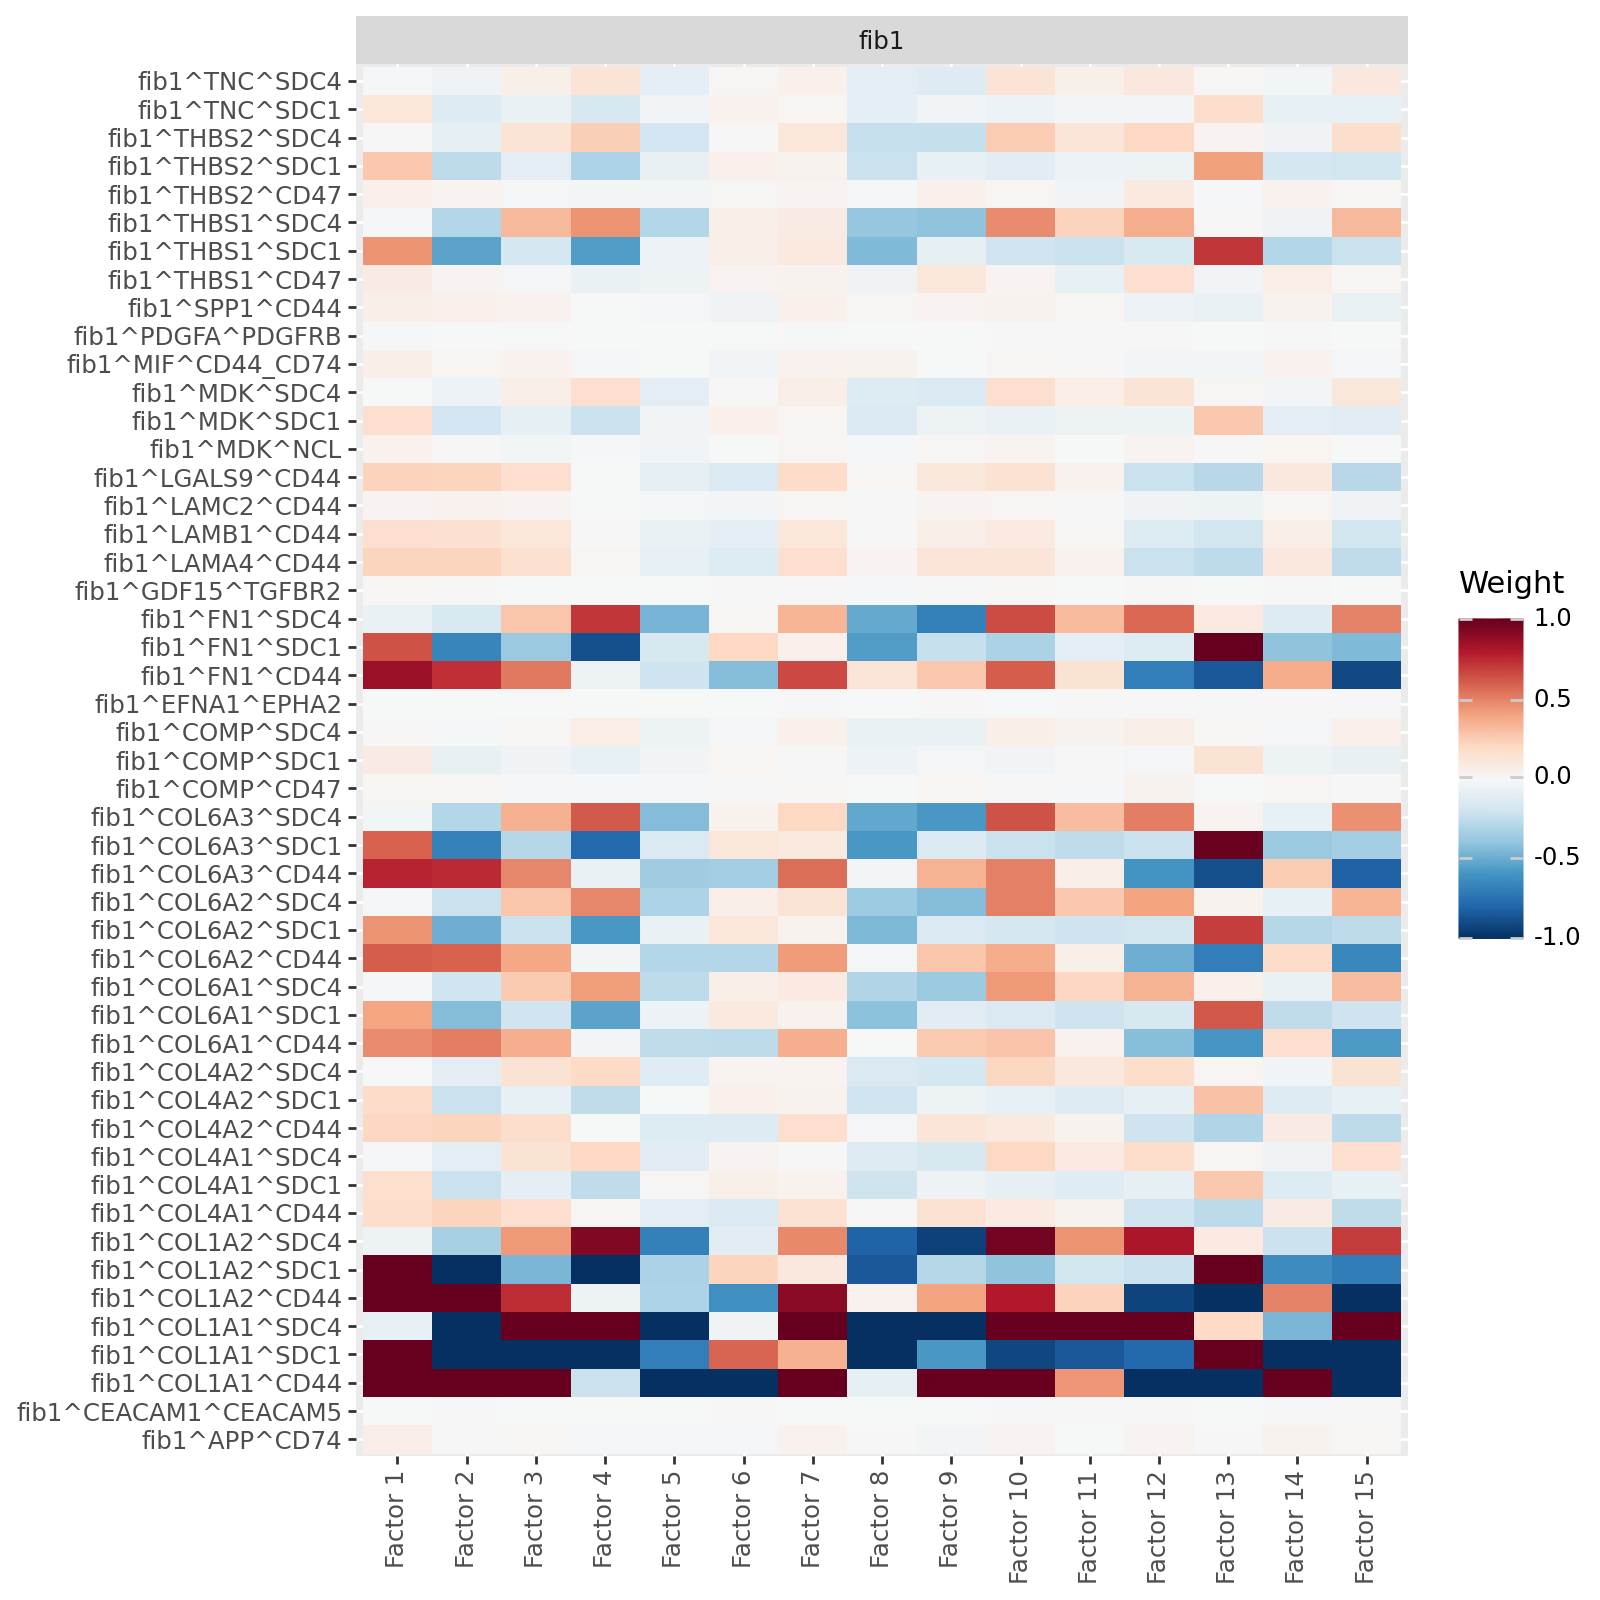

In [40]:
mfl.pl.all_weights(model, views=['fib1'], figsize=(8,8), show_featurenames=True)

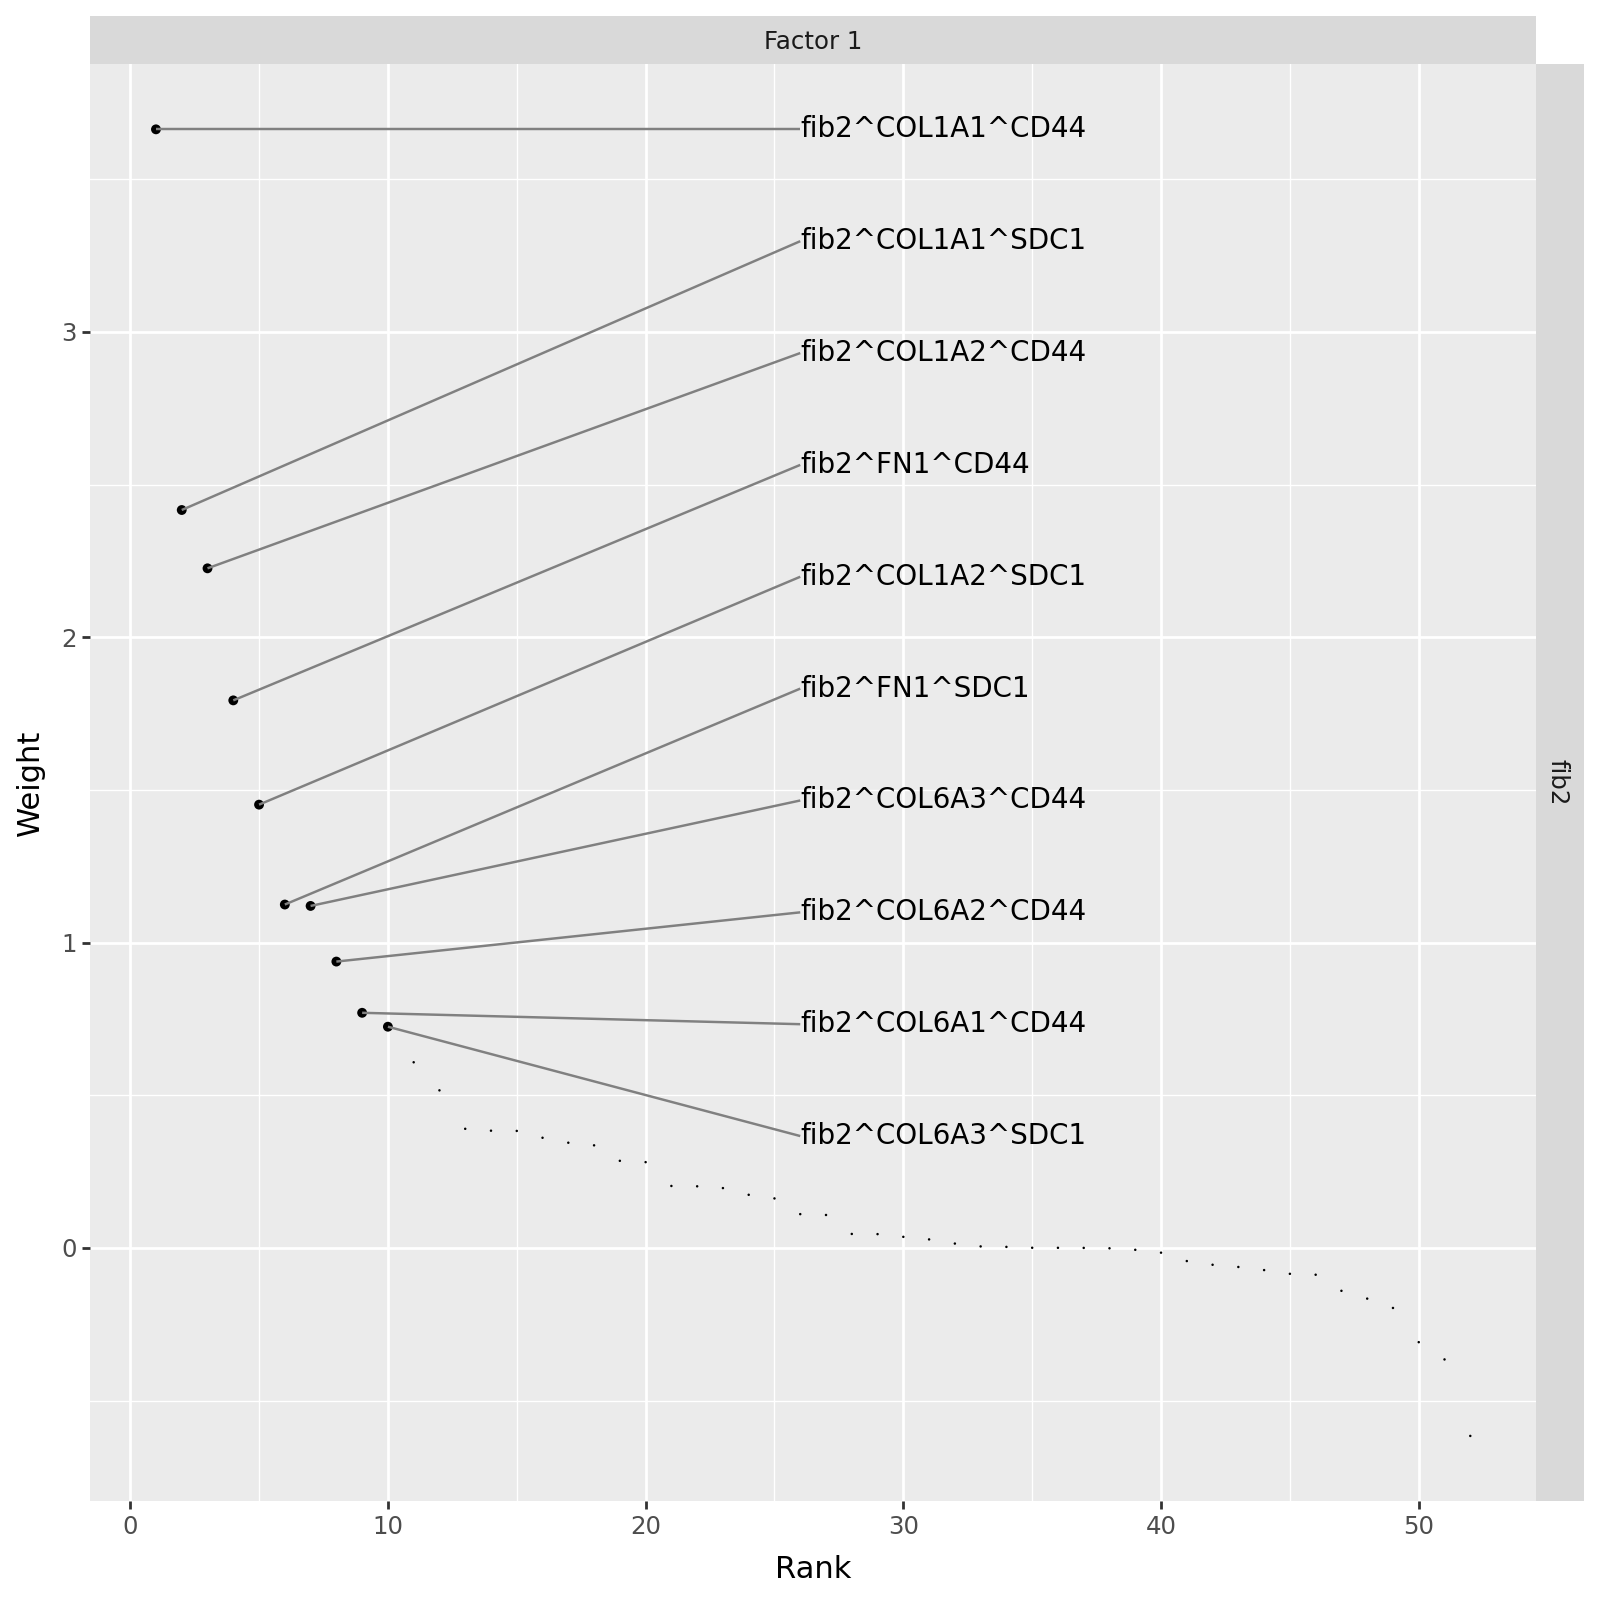

In [122]:
mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))

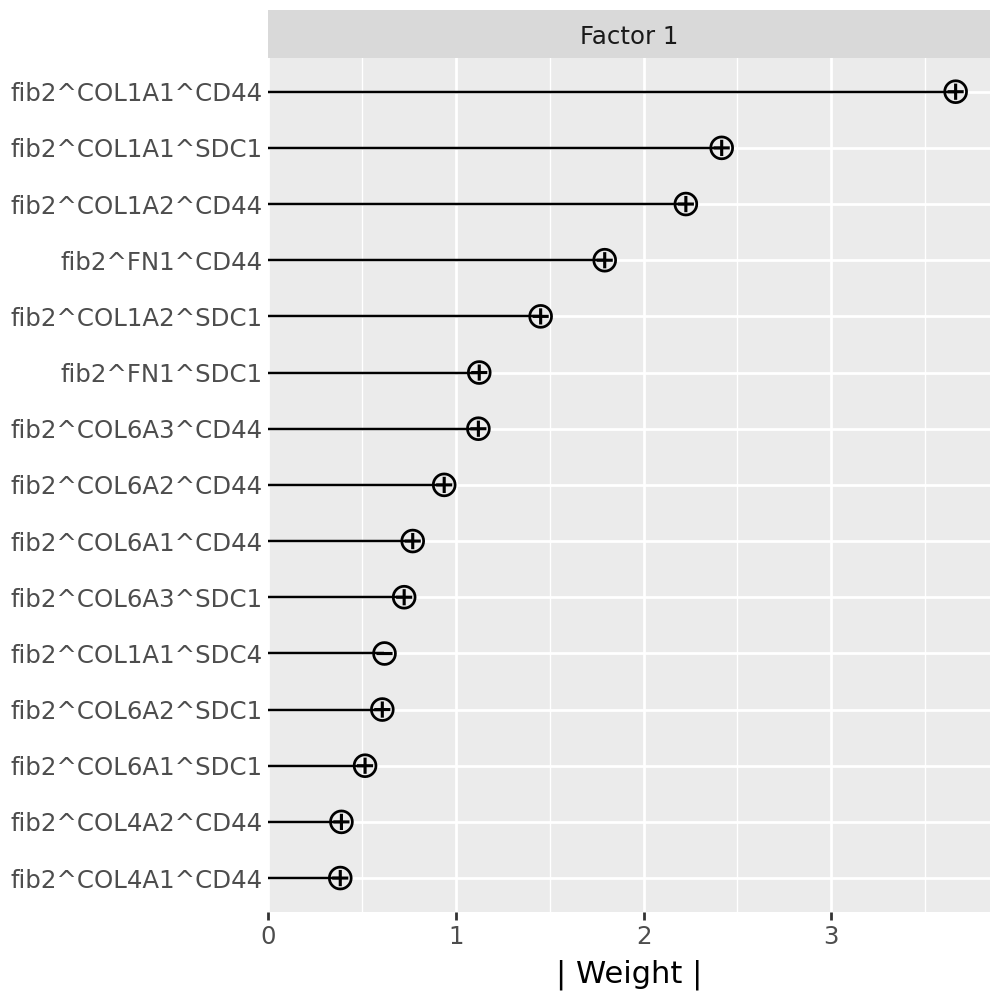

In [123]:
mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

In [14]:
weights = model_nor.get_weights()
factors = model_nor.get_factors()

In [16]:
factors

{'group_1':               Factor 1  Factor 2  Factor 3  Factor 4  Factor 5  Factor 6  \
 c_3_154_37    0.085426  0.134153  0.951666 -0.497316 -0.908589 -0.374591   
 c_3_154_43    0.302522 -0.037855  0.501170 -0.022138 -0.543980  0.097037   
 c_3_154_61   -0.178582 -0.472574  0.582427 -0.283238 -0.009777  0.253981   
 c_3_154_69   -0.112379 -0.095783 -0.310092  0.297999 -0.333418 -0.149187   
 c_3_154_75   -0.106441  0.214625 -0.231379 -0.212068 -0.355736 -0.345462   
 ...                ...       ...       ...       ...       ...       ...   
 c_3_163_214   0.684093 -0.017714  0.160284 -0.627853 -0.033214 -0.165567   
 c_3_163_1843 -0.731374 -0.928795  1.742167 -0.319425 -0.465075  0.914405   
 c_3_163_2575  0.756079 -0.996664 -0.594713 -0.554859 -0.038884 -0.083340   
 c_3_164_158  -0.895086 -0.670308 -0.687510  0.233258  1.254605  0.189812   
 c_3_164_179   1.101907 -0.695335  0.594179 -0.099233  0.676640 -0.623336   
 
               Factor 7  Factor 8  Factor 9  Factor 10  Factor 

In [99]:
import scanpy as sc

## Cell type

/tmp/ipykernel_1781148/92103645.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


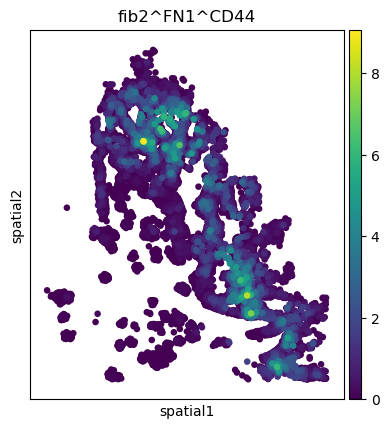

/tmp/ipykernel_1781148/92103645.py:13: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


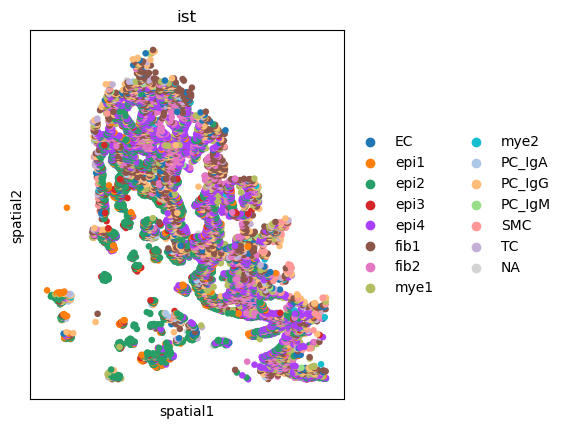

In [125]:
import scanpy as sc

# Extract the AnnData from MuData
adata = mdata.mod['fib2']

# Plot spatial
sc.pl.spatial(
    adata,
    color='fib2^FN1^CD44',   # replace with your gene or obs column
    spot_size=100,   # adjust for your data
)
# Plot spatial
sc.pl.spatial(
    adata,
    color='ist',   # replace with your gene or obs column
    spot_size=100,   # adjust for your data
)


In [66]:
import pandas as pd

dfs = []
for mod_name, ad in mdata.mod.items():
    if "spatial" in ad.obsm:
        df = pd.DataFrame(
            ad.obsm["spatial"],
            columns=["spatial1", "spatial2"],
            index=ad.obs_names
        )
        # add modality column + any metadata you want
        df["modality"] = mod_name
        dfs.append(df)

# Combine into one DataFrame
spatial_df = pd.concat(dfs)

# See result
print(spatial_df.head())
print(spatial_df.shape)


              spatial1     spatial2 modality
c_3_154_37  9040.72592  12181.23672     epi4
c_3_154_43  8995.01952  12177.50804     epi4
c_3_154_61  8971.32436  12171.49404     epi4
c_3_154_69  9086.31204  12169.20872     epi4
c_3_154_75  9130.81564  12169.32900     epi4
(80909, 3)


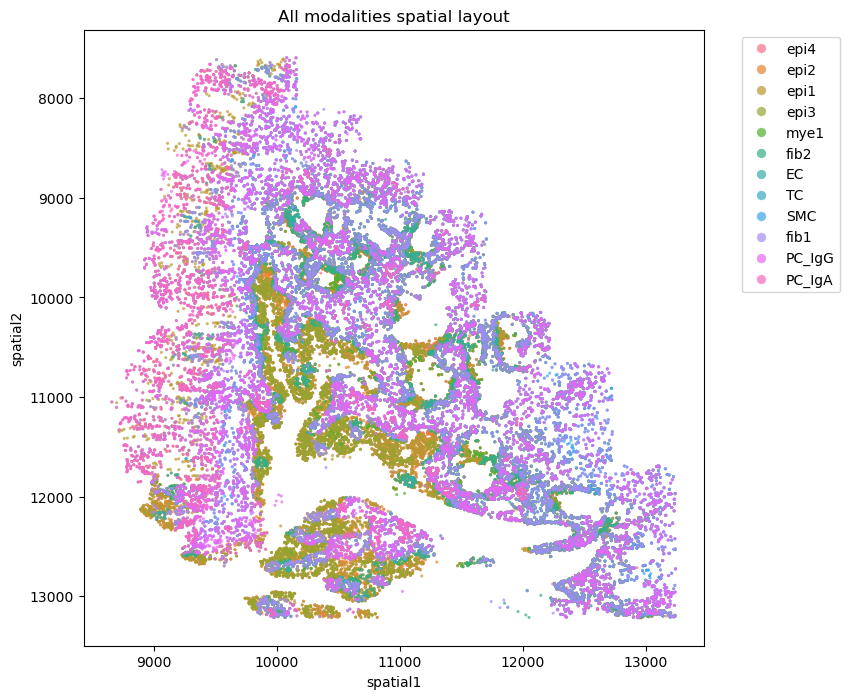

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=spatial_df,
    x="spatial1",
    y="spatial2",
    hue="modality",     # color by modality
    s=5,                # point size
    alpha=0.7,          # transparency
    linewidth=0
)
plt.gca().invert_yaxis()  # Visium-style: origin at top-left
plt.title("All modalities spatial layout")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_ydensity : Removed 1 rows containing non-finite values.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_sina : Removed 1 rows containing non-finite values.


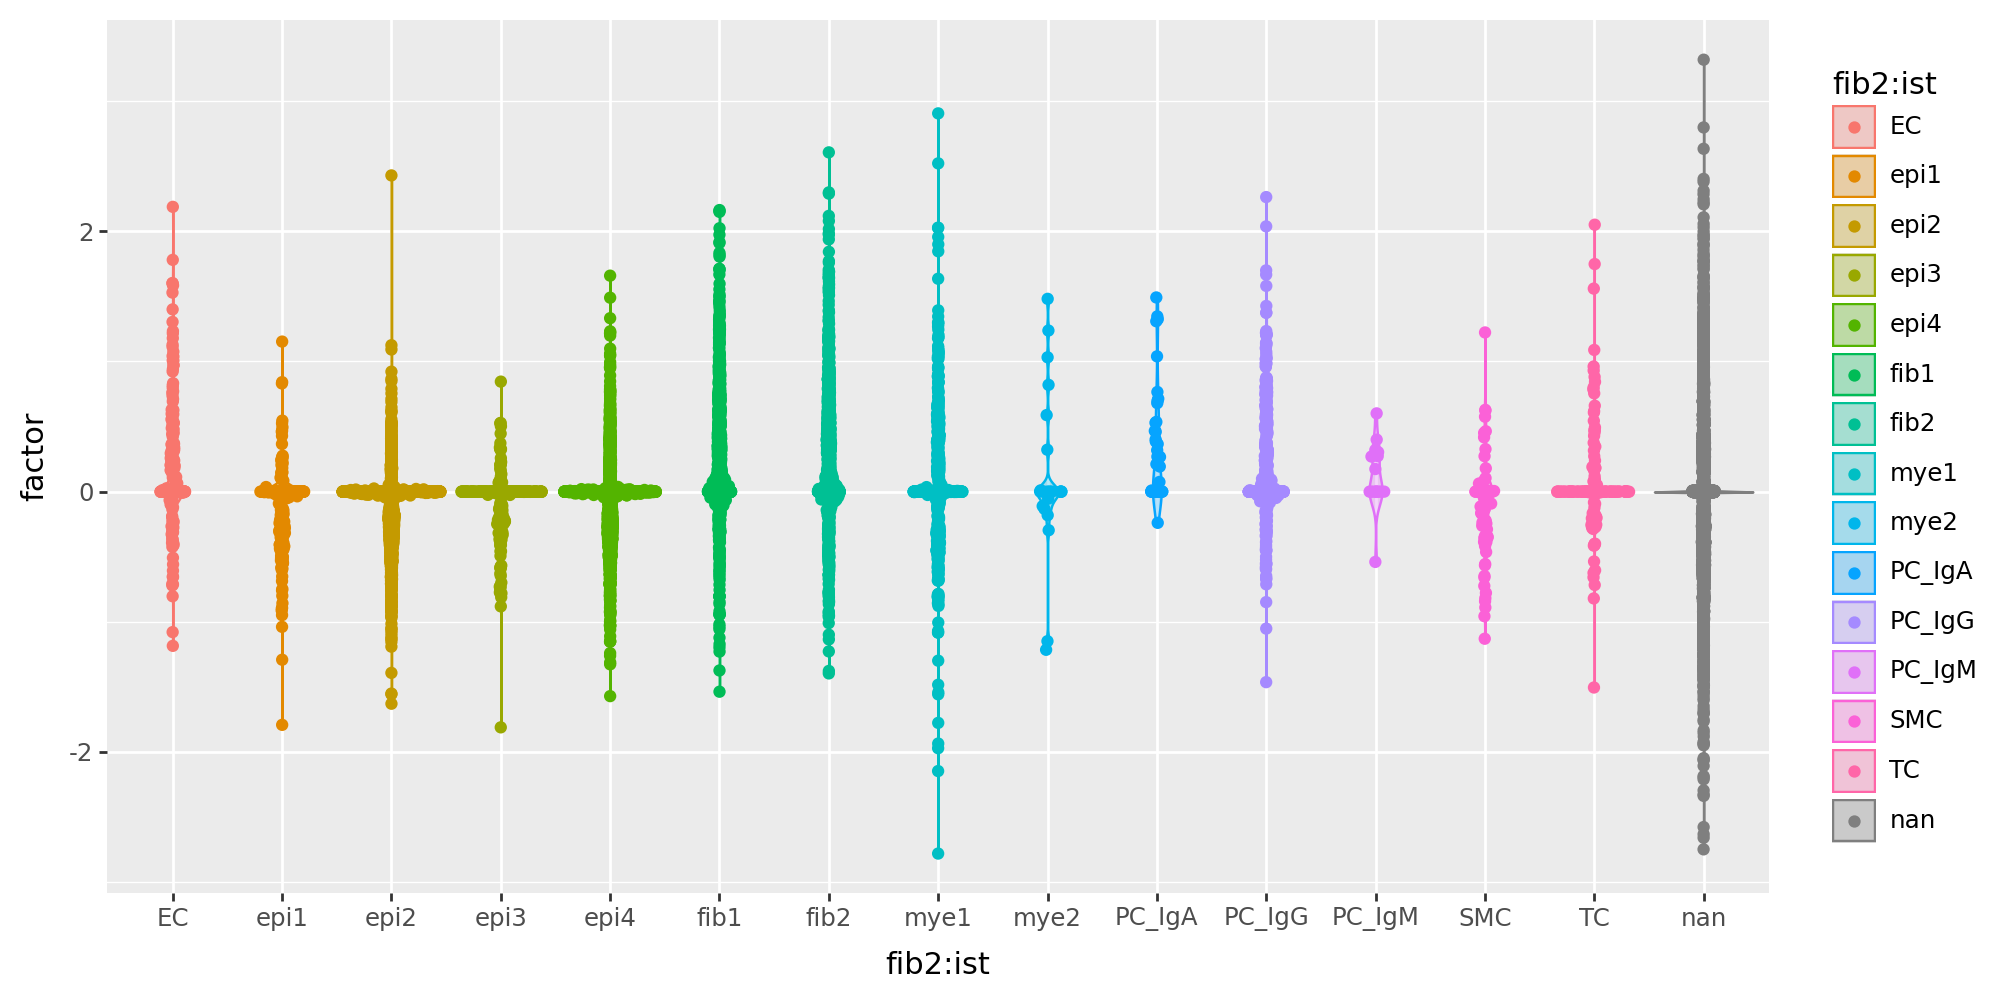

In [126]:
from plotnine import theme

cell_type = "fib2:ist"
factor = "Factor 1"

(
    ggplot(
        mdata.obs[[cell_type]].assign(
            factor=model.get_factors()["group_1"][factor]
        ),
        aes(cell_type, "factor", color=cell_type, fill=cell_type),
    )
    + geom_violin(alpha=0.3)
    + geom_sina()
    + theme(figure_size=(10, 5)) 
)


In [127]:
factor = "Factor 1"

f1 = factors["group_1"][factor]          
# make sure index are cell IDs (same strings as in adata.obs_names)
assert isinstance(f1, pd.Series)

for mod in mdata_new.mod:                         # e.g., "epi1", "fib1", "SMC", ...
    ad = mdata_new.mod[mod]
    ad.obs[factor] = np.nan
    common = ad.obs_names.intersection(f1.index)
    ad.obs.loc[common, factor] = f1.loc[common].astype(float).values


/tmp/ipykernel_1781148/3546650425.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


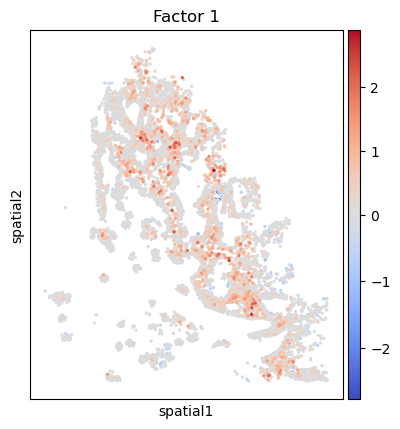

In [128]:
# Single modality
cell_type = "fib2"

sc.pl.spatial(
    mdata_new.mod[cell_type], 
    color=factor,
    cmap="coolwarm",        # diverging colormap is best here
    vcenter=0,              # center at 0 because your weights have +/-
    na_color="#dddddd",
    spot_size =50               # tune for your spot size
)

# lrdata

In [13]:
import scanpy as sc

In [14]:
lrdata = sc.read("/g/stegle/aalsayah/repos/data/lrdata/lrdata_232.h5ad")

In [129]:
factor = "Factor 1"
f = factors["group_1"][factor]          
assert isinstance(f, pd.Series)
lrdata.obs[factor] = f.reindex(lrdata.obs_names).astype(float)

/tmp/ipykernel_1781148/3731828912.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_1781148/3731828912.py:15: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


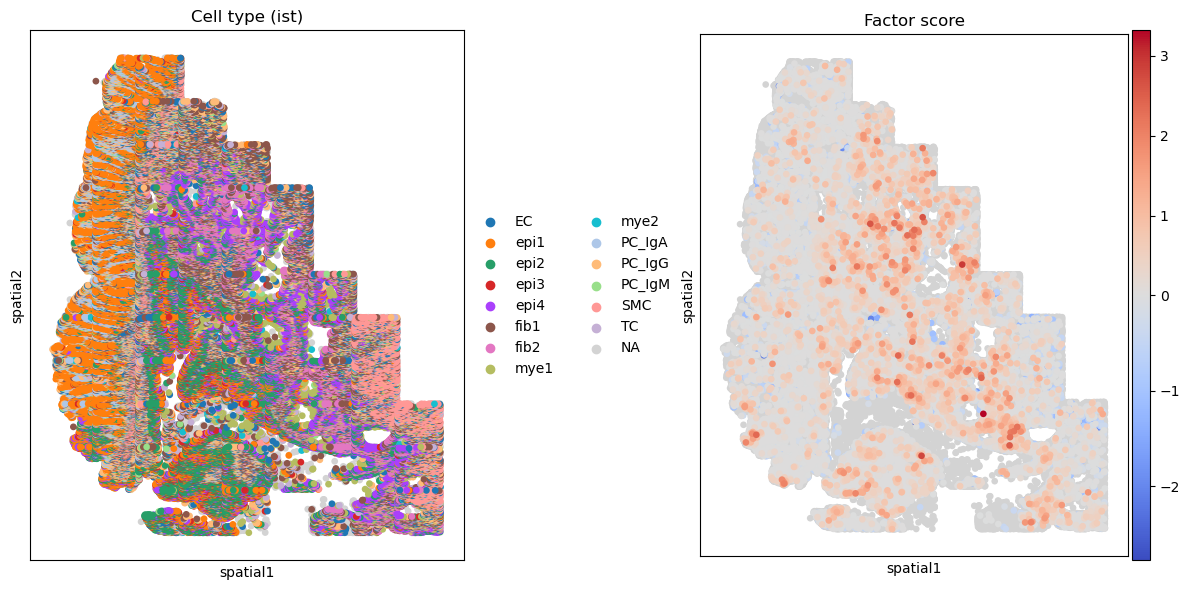

In [130]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Left: cell type
sc.pl.spatial(
    lrdata,
    color="ist",
    spot_size=80,
    ax=axes[0],
    show=False
)
axes[0].set_title("Cell type (ist)")

# Right: Factor 
sc.pl.spatial(
    lrdata,
    color=factor,
    cmap="coolwarm",
    vcenter=0,
    spot_size=80,
    ax=axes[1],
    show=False
)
axes[1].set_title("Factor score")

plt.tight_layout()
plt.show()


/tmp/ipykernel_1781148/4001685307.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
/tmp/ipykernel_1781148/4001685307.py:15: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


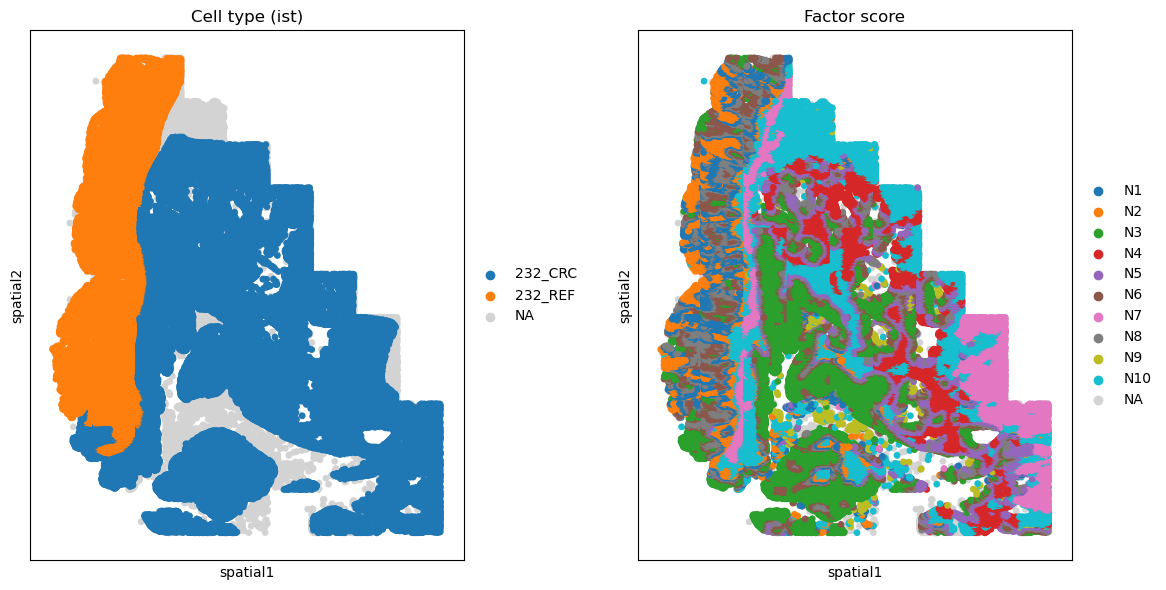

In [118]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Left: cell type
sc.pl.spatial(
    lrdata,
    color="typ",
    spot_size=80,
    ax=axes[0],
    show=False
)
axes[0].set_title("t")

# Right: Factor 
sc.pl.spatial(
    lrdata,
    color="ctx",
    cmap="coolwarm",
    vcenter=0,
    spot_size=80,
    ax=axes[1],
    show=False
)
axes[1].set_title("niches")

plt.tight_layout()
plt.show()


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_ydensity : Removed 1 rows containing non-finite values.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_sina : Removed 1 rows containing non-finite values.


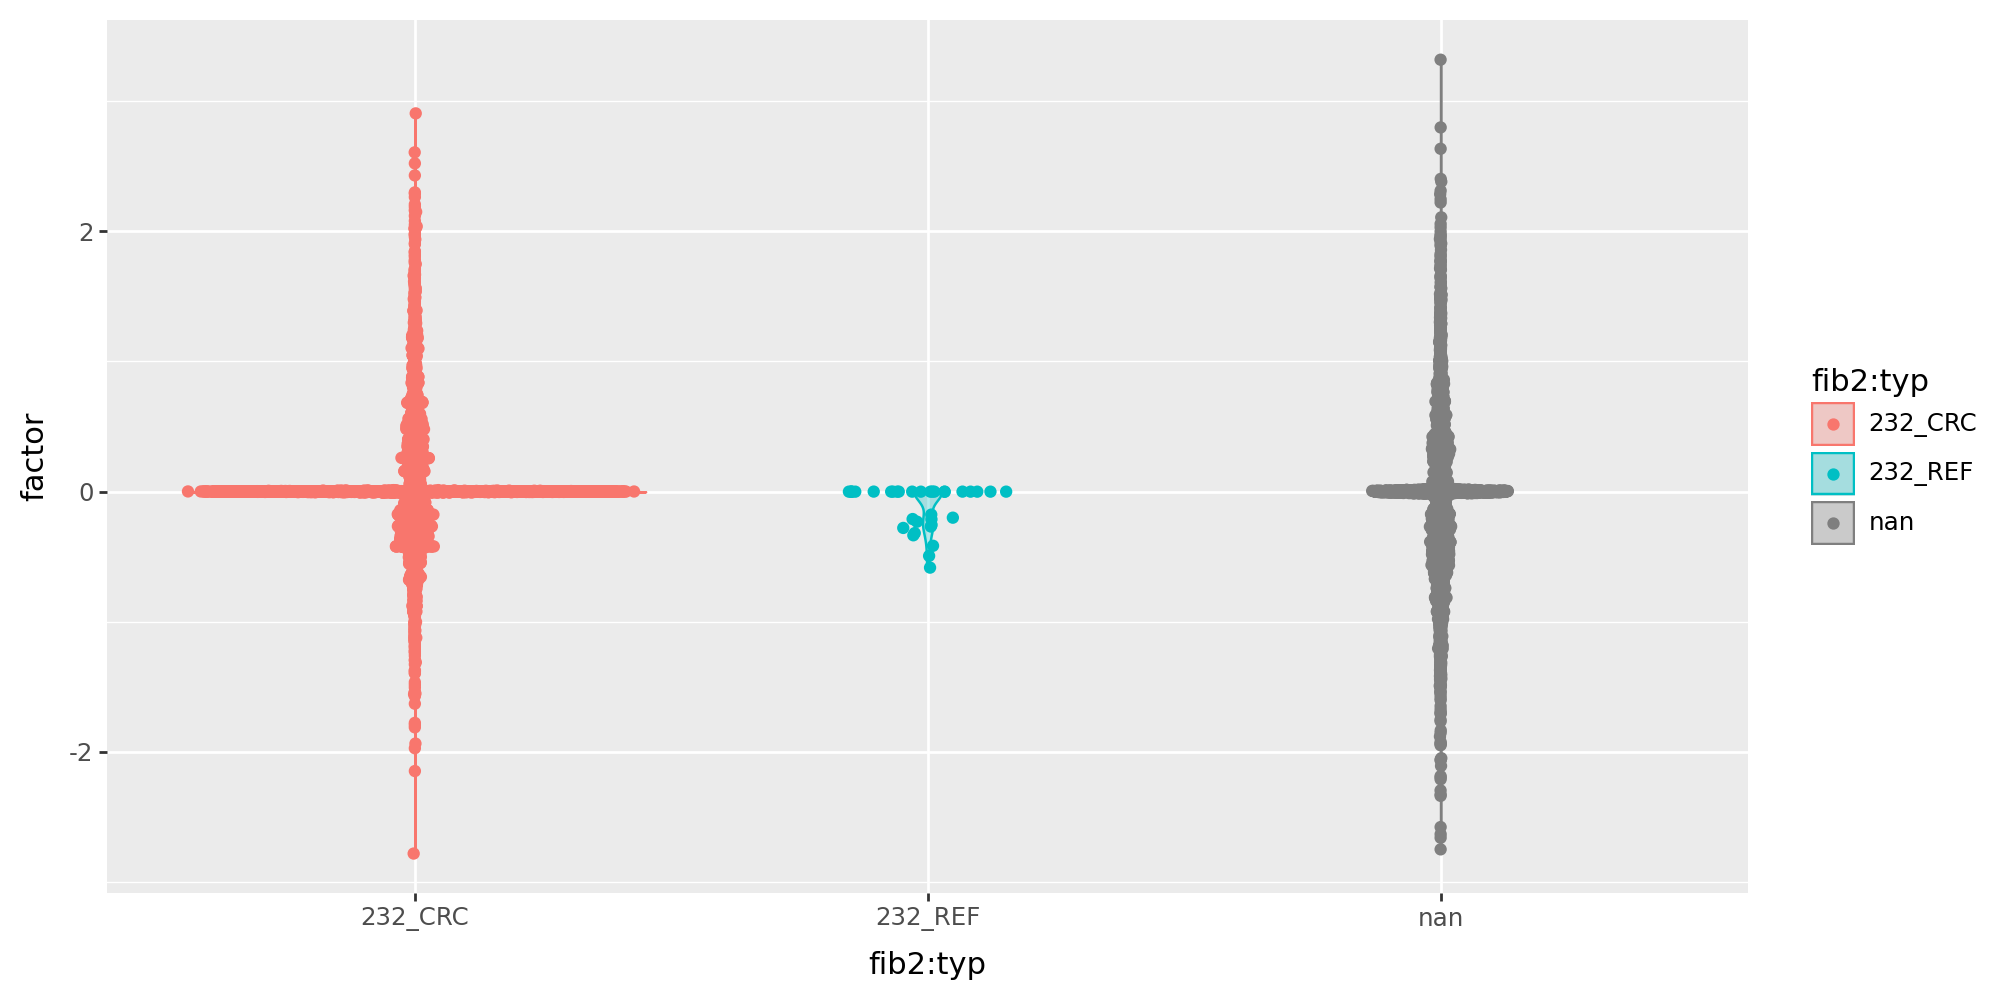

In [131]:
from plotnine import theme

cell_type = "fib2:typ"
factor = "Factor 1"

(
    ggplot(
        mdata.obs[[cell_type]].assign(
            factor=model.get_factors()["group_1"][factor]
        ),
        aes(cell_type, "factor", color=cell_type, fill=cell_type),
    )
    + geom_violin(alpha=0.3)
    + geom_sina()
    + theme(figure_size=(10, 5)) 
)


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_ydensity : Removed 1 rows containing non-finite values.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_sina : Removed 1 rows containing non-finite values.


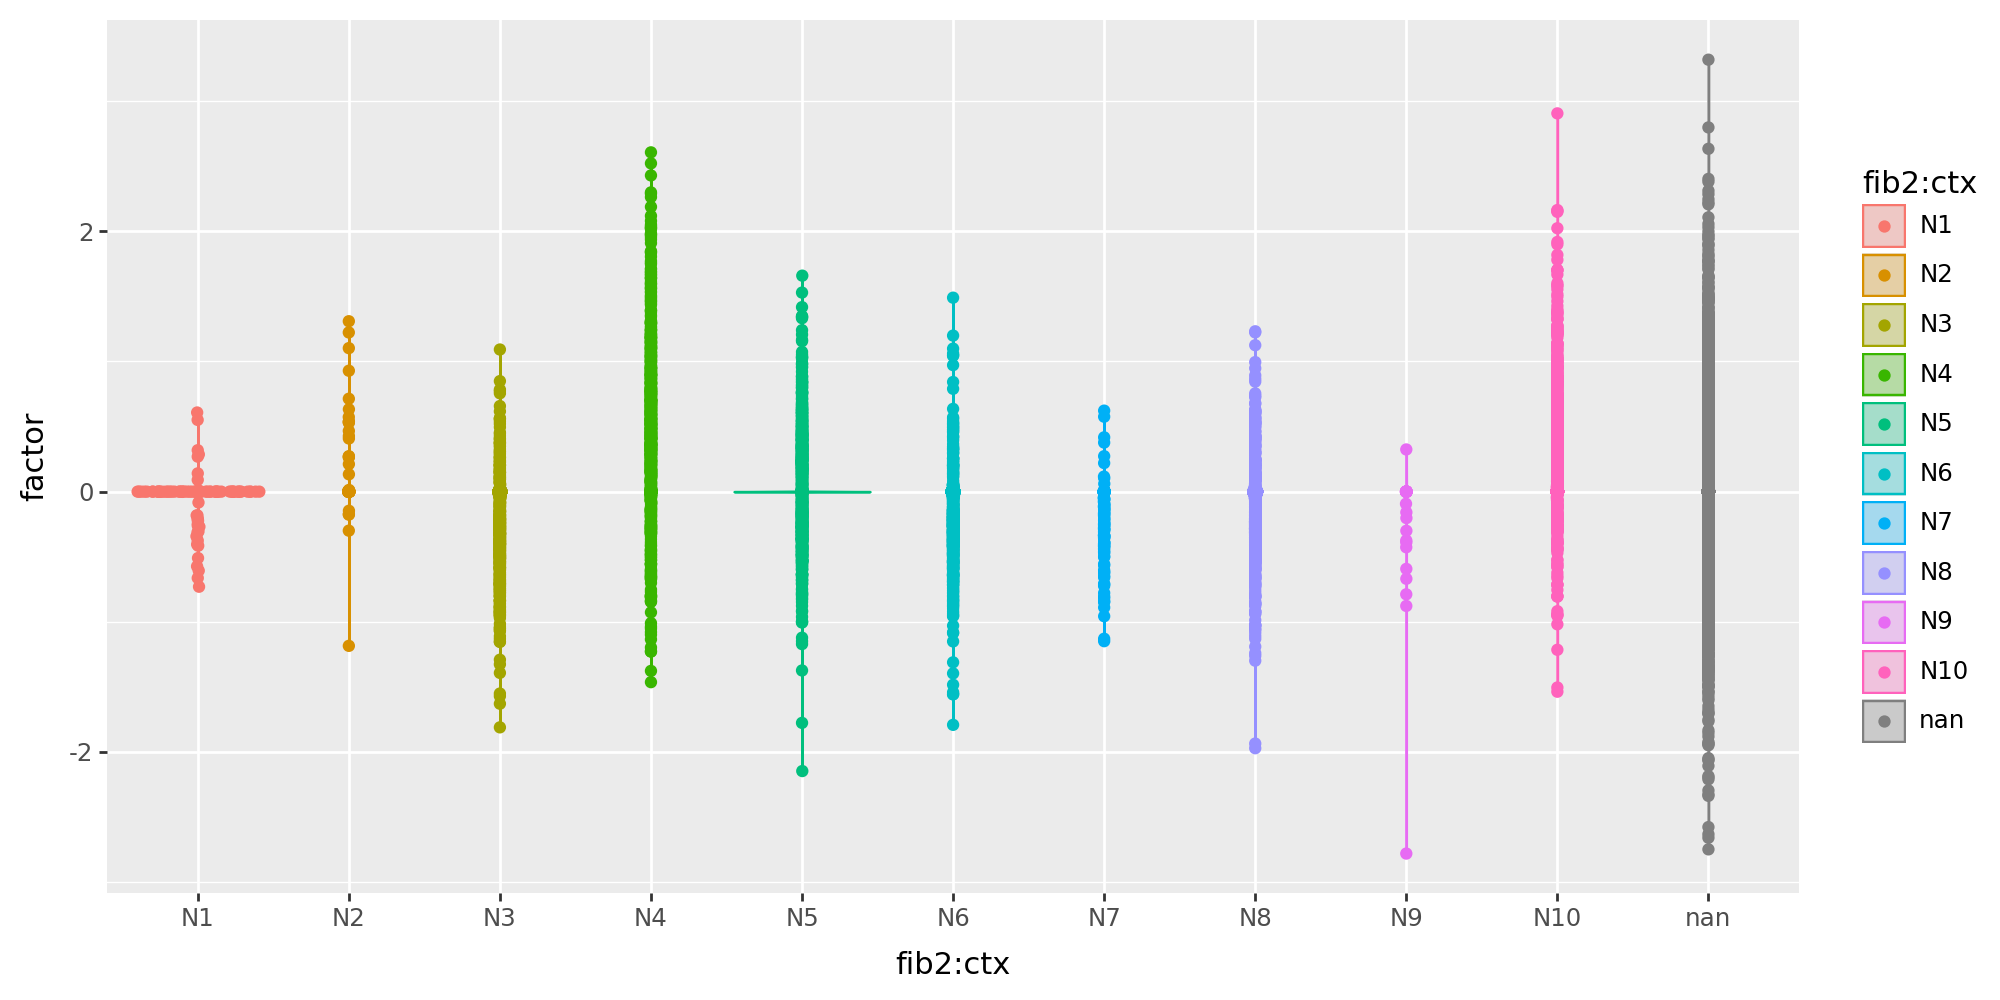

In [132]:
from plotnine import theme

cell_type = "fib2:ctx"
factor = "Factor 1"

(
    ggplot(
        mdata.obs[[cell_type]].assign(
            factor=model.get_factors()["group_1"][factor]
        ),
        aes(cell_type, "factor", color=cell_type, fill=cell_type),
    )
    + geom_violin(alpha=0.3)
    + geom_sina()
    + theme(figure_size=(10, 5)) 
)


# coefficient of determination (R²)

why? 
<br>

This value reflects how well a regression model explains the variability of the dependent variable.
In simple terms, it tells you how much of the variation in the outcome (Y) can be explained by the predictor(s) (X) in your model.

Our aim here is to calculate ONE R² value per model. Just to say: which prior perform well in explaining the variability in the data?
Spike-and-slab vs. Normal vs. Gussian?
 
How?


In [10]:
import numpy as np
from typing import Dict, List, Tuple

def _to_list(x, all_names):
    if x == "all":
        return list(all_names)
    if isinstance(x, (list, tuple)):
        return list(x)
    return [x]

def calculate_variance_explained(
    W: Dict[str, np.ndarray],                 # view -> (D_m, K)
    Z: Dict[str, np.ndarray],                 # group -> (N_g, K)
    Y: Dict[str, Dict[str, np.ndarray]],      # view -> group -> (N_g, D_m)
    views="all", groups="all", factors="all"
) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    """
    Returns:
      r2_total: dict[group] -> array shape (len(views),) with R^2 (%) per view
      r2_per_factor: dict[group] -> array shape (len(factors), len(views)) with R^2 (%) per factor & view
    """
    view_names  = list(W.keys())
    group_names = list(Z.keys())
    K_all       = W[view_names[0]].shape[1]

    views   = _to_list(views, view_names)
    groups  = _to_list(groups, group_names)
    if factors == "all":
        factor_idx = list(range(K_all))
    else:
        factor_idx = [int(k) for k in factors]  # zero-based indexing

    # Replace masked Z values (NaN) by 0 so they don't contribute
    Z = {g: np.nan_to_num(Z[g], nan=0.0) for g in groups}

    # --- total R2 per (group, view)
    r2_total = {}
    for g in groups:
        vals = []
        Zg = Z[g]  # (N_g, K)
        for m in views:
            Ym = Y[m][g]            # (N_g, D_m)
            Wm = W[m]               # (D_m, K)
            Yhat = Zg @ Wm.T        # (N_g, D_m)
            num = np.nansum((Ym - Yhat)**2)
            den = np.nansum(Ym**2)
            r2 = 0.0 if den == 0 else max(0.0, 1.0 - num/den)
            vals.append(100.0 * r2)
        r2_total[g] = np.array(vals)  # order matches 'views'

    # --- per-factor R2 per (group, factor, view)
    r2_per_factor = {}
    for g in groups:
        Zg = Z[g]  # (N_g, K)
        rows = []
        for k in factor_idx:
            row = []
            zk = Zg[:, [k]]  # (N_g, 1)
            for m in views:
                Ym = Y[m][g]              # (N_g, D_m)
                wk = W[m][:, [k]]         # (D_m, 1)
                Yhat_k = zk @ wk.T        # (N_g, D_m)
                num = np.nansum((Ym - Yhat_k)**2)
                den = np.nansum(Ym**2)
                r2 = 0.0 if den == 0 else max(0.0, 1.0 - num/den)
                row.append(100.0 * r2)
            rows.append(row)
        r2_per_factor[g] = np.array(rows)  # shape: (len(factors), len(views))

    return r2_total, r2_per_factor

def calculate_variance_explained_per_sample(
    W: Dict[str, np.ndarray],                # view -> (D_m, K)
    Z: Dict[str, np.ndarray],                # group -> (N_g, K)
    Y: Dict[str, Dict[str, np.ndarray]],     # view -> group -> (N_g, D_m)
    views="all", groups="all", factors="all"
) -> Dict[str, np.ndarray]:
    """
    Returns:
      dict[group] -> array shape (N_g, len(views)) with per-sample R^2 (%) per view
    """
    view_names  = list(W.keys())
    group_names = list(Z.keys())
    K_all       = W[view_names[0]].shape[1]

    views   = _to_list(views, view_names)
    groups  = _to_list(groups, group_names)
    if factors == "all":
        factor_idx = list(range(K_all))
    else:
        factor_idx = [int(k) for k in factors]

    Z = {g: np.nan_to_num(Z[g], nan=0.0) for g in groups}

    r2_ps = {}
    for g in groups:
        Zg = Z[g][:, factor_idx]  # (N_g, K_sel)
        group_rows = []
        for m in views:
            Wm = W[m][:, factor_idx]        # (D_m, K_sel)
            Ym = Y[m][g]                    # (N_g, D_m)
            Yhat = Zg @ Wm.T                # (N_g, D_m)
            num = np.nansum((Ym - Yhat)**2, axis=1)  # per-row
            den = np.nansum(Ym**2, axis=1)
            # safe division row-wise
            with np.errstate(divide='ignore', invalid='ignore'):
                r2 = 1.0 - np.where(den == 0, 0.0, num/den)
            r2 = np.clip(r2, 0.0, None) * 100.0
            group_rows.append(r2.reshape(-1, 1))
        r2_ps[g] = np.hstack(group_rows)  # (N_g, len(views))
    return r2_ps


In [11]:
W = model_nor.get_weights()

In [15]:
Z = model_nor.get_factors()

In [15]:
import numpy as np
from scipy import sparse

def build_Y_from_mudata(mdata, group_name="group_1", layer=None, use_raw=False, as_dataframe=False):
    """
    Build Y[view][group] = (n_samples_in_group x n_features_in_view) arrays (or DataFrames)
    from a MuData object with a single synthetic group.
    
    - layer: name of AnnData .layers[] to use; if None, uses .X
    - use_raw: if True and .raw is set, use .raw.X / .raw.var_names
    - as_dataframe: if True, return pandas DataFrames with obs/var names
    """
    Y = {}
    meta = {}  # optional: keep obs/var names per view

    for view, ad in mdata.mod.items():
        # pick matrix source
        if use_raw and ad.raw is not None:
            X_view = ad.raw.X
            var_names = ad.raw.var_names.to_list()
        elif layer is not None and layer in ad.layers:
            X_view = ad.layers[layer]
            var_names = ad.var_names.to_list()
        else:
            X_view = ad.X
            var_names = ad.var_names.to_list()

        # ensure dense numpy array
        if sparse.issparse(X_view):
            X_view = X_view.toarray()
        else:
            X_view = np.asarray(X_view)

        # wrap into single-group structure
        if as_dataframe:
            import pandas as pd
            df = pd.DataFrame(X_view, index=ad.obs_names, columns=var_names)
            Y.setdefault(view, {})[group_name] = df
        else:
            Y.setdefault(view, {})[group_name] = X_view

        # store metadata (handy later)
        meta[view] = {"obs_names": ad.obs_names.to_list(), "var_names": var_names}

    return Y, meta

In [16]:
Y, meta = build_Y_from_mudata(mdata_new, group_name="group_1")
for view, groups in Y.items():
    arr = groups["group_1"]

In [19]:
model_nor._save("/g/stegle/aalsayah/repos/data/mofa_models/mofaflex_normal_full", mofa_compat="full", data=Y)

ValueError: Need both data and intercepts if saving data in MOFA compatibility mode.

In [21]:
print(dir(mfl.TrainingOptions.mofa_compat))

['__abs__', '__add__', '__and__', '__bool__', '__ceil__', '__class__', '__delattr__', '__dir__', '__divmod__', '__doc__', '__eq__', '__float__', '__floor__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__index__', '__init__', '__init_subclass__', '__int__', '__invert__', '__le__', '__lshift__', '__lt__', '__mod__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rlshift__', '__rmod__', '__rmul__', '__ror__', '__round__', '__rpow__', '__rrshift__', '__rshift__', '__rsub__', '__rtruediv__', '__rxor__', '__setattr__', '__sizeof__', '__str__', '__sub__', '__subclasshook__', '__truediv__', '__trunc__', '__xor__', 'as_integer_ratio', 'bit_count', 'bit_length', 'conjugate', 'denominator', 'from_bytes', 'imag', 'numerator', 'real', 'to_bytes']


In [29]:
W["mye1"].shape

(15, 49)

In [21]:
r2_total, r2_per_factor = calculate_variance_explained(W, Z, Y)

ValueError: shapes (20377, 15) and (49, 15) not aligned

In [ ]:
r2_per_sample = calculate_variance_explained_per_sample(W, Z, Y)